In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging


working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)



# dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42 

Running Scanpy 1.11.3, on 2025-10-22 14:37.


In [11]:
FB_adata = sc.read ('/data2/core-med1/elindber/PROJECTS/20231020_el_Xenotransplant/results/20240220_el_Xenotransplant_BR_FB_PIG_2ndIT_ANNOTATED.h5ad')

In [12]:
FB_adata

AnnData object with n_obs × n_vars = 16322 × 3571
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'leiden_07'
    var: 'Average_expression', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Endpoint_status_colors', 'Sample_ID_colors', 'cell_states_colors', 'hvg', 'leiden', 'leiden_07_colors', 'leiden_08_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp

In [13]:
raw_FB_adata= anndata.AnnData(X=FB_adata.raw.X,
                obs=FB_adata.obs, 
                var=FB_adata.raw.var)

In [14]:
raw_FB_adata

AnnData object with n_obs × n_vars = 16322 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'pCMV_score', 'n_counts_pCMV', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'leiden_08', 'cell_states', 'leiden_07'
    var: 'Average_expression'

In [4]:
global_raw = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/global objects/global_v7/global_v7_without_unassigned/20240220_el_Xenotransplant_noBR_ANNOTATED_pc39_noreg_CELL_STATES_RAWRAW_with_condition_subsets_v7_no_unassigned.h5ad')

In [5]:
new_adata = global_raw.copy()

# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(new_adata)
sc.pp.log1p(new_adata)

In [8]:
global_FB_adata = new_adata [new_adata.obs.cell_type == 'Fibroblasts']

In [9]:
global_FB_adata

View of AnnData object with n_obs × n_vars = 16322 × 53826
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    var: 'Average_expression'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [9]:
import pandas as pd
import scanpy as sc

# Assuming FB_adata is already loaded

# Get the groups (cell states)
groups = FB_adata.uns['rank_genes_groups']['names'].dtype.names

# For each group (cell state), extract markers and save as CSV
for group in groups:
    names      = FB_adata.uns['rank_genes_groups']['names'][group]
    scores     = FB_adata.uns['rank_genes_groups']['scores'][group]
    logfoldchanges = FB_adata.uns['rank_genes_groups']['logfoldchanges'][group]
    pvals      = FB_adata.uns['rank_genes_groups']['pvals'][group]
    pvals_adj  = FB_adata.uns['rank_genes_groups']['pvals_adj'][group]

    df = pd.DataFrame({
        'gene': names,
        'score': scores,
        'logfoldchange': logfoldchanges,
        'pval': pvals,
        'pval_adj': pvals_adj
    })

    # Save as CSV; e.g. cellstate_markers_v1_vFB1.csv
    outpath = f'markers_{group}.csv'
    df.to_csv(outpath, index=False)
    print(f'Saved: {outpath}')


Saved: markers_vFB1.csv
Saved: markers_vFB2.csv
Saved: markers_vFB3.csv
Saved: markers_vFB4.csv
Saved: markers_vFB5.csv
Saved: markers_vFB6.csv
Saved: markers_vFB7.csv
Saved: markers_vFB8.csv
Saved: markers_vFB9.csv
Saved: markers_vFB10.csv


In [11]:
groups = FB_adata.uns['rank_genes_groups']['names'].dtype.names

for group in groups:
    names      = FB_adata.uns['rank_genes_groups']['names'][group]
    scores     = FB_adata.uns['rank_genes_groups']['scores'][group]
    logfoldchanges = FB_adata.uns['rank_genes_groups']['logfoldchanges'][group]
    pvals      = FB_adata.uns['rank_genes_groups']['pvals'][group]
    pvals_adj  = FB_adata.uns['rank_genes_groups']['pvals_adj'][group]

    df = pd.DataFrame({
        'gene': names,
        'score': scores,
        'logfoldchange': logfoldchanges,
        'pval': pvals,
        'pval_adj': pvals_adj
    })

    # Filter
    df_filtered = df[(df['logfoldchange'] > 0.5) & (df['pval'] < 0.05)]

    # Save
    outpath = f'markers_{group}_filtered.csv'
    df_filtered.to_csv(outpath, index=False)
    print(f'Saved: {outpath} (n={len(df_filtered)})')


Saved: markers_vFB1_filtered.csv (n=78)
Saved: markers_vFB2_filtered.csv (n=2013)
Saved: markers_vFB3_filtered.csv (n=275)
Saved: markers_vFB4_filtered.csv (n=4087)
Saved: markers_vFB5_filtered.csv (n=349)
Saved: markers_vFB6_filtered.csv (n=472)
Saved: markers_vFB7_filtered.csv (n=512)
Saved: markers_vFB8_filtered.csv (n=957)
Saved: markers_vFB9_filtered.csv (n=628)
Saved: markers_vFB10_filtered.csv (n=2996)


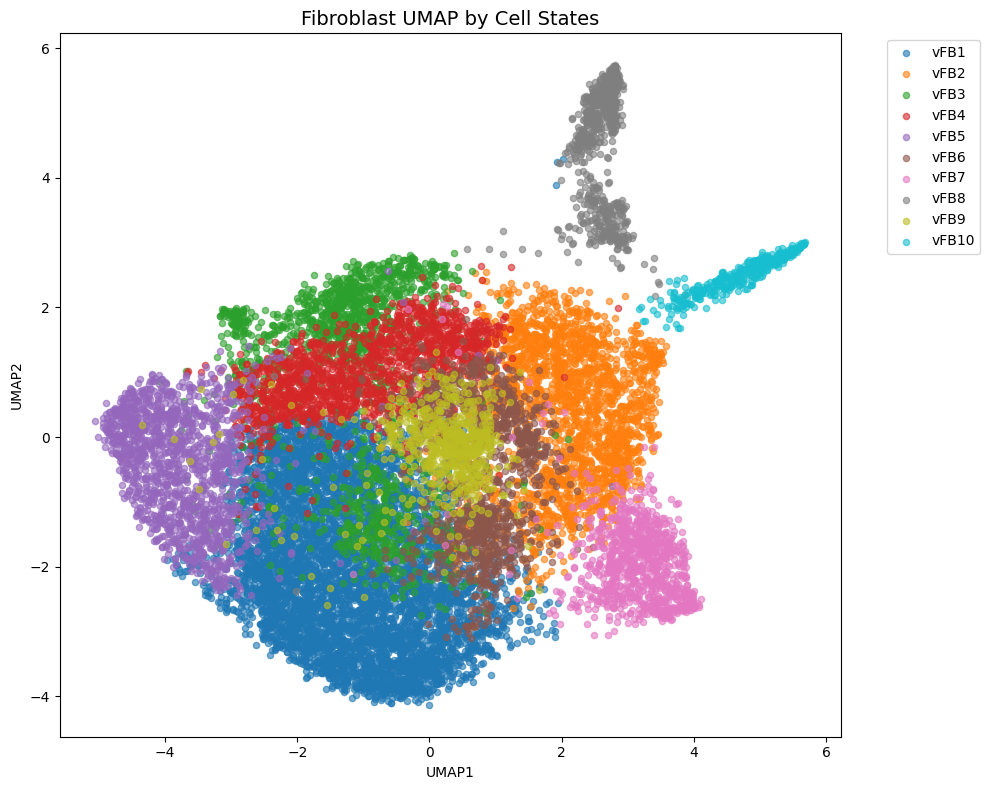

In [15]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure cell_states is properly formatted as categorical
FB_adata.obs['cell_states'] = FB_adata.obs['cell_states'].astype('category')

# 2. Verify colors exist and match categories
if 'cell_states_colors' not in FB_adata.uns:
    print("Creating default colors for cell states")
    n_states = len(FB_adata.obs['cell_states'].cat.categories)
    FB_adata.uns['cell_states_colors'] = plt.cm.tab20(np.linspace(0, 1, n_states))

# 3. Create a dictionary mapping states to colors
state_color_map = dict(zip(
    FB_adata.obs['cell_states'].cat.categories,
    FB_adata.uns['cell_states_colors']
))

# 4. Plot with enforced color mapping
fig, ax = plt.subplots(figsize=(10, 8))
for state, color in state_color_map.items():
    mask = FB_adata.obs['cell_states'] == state
    ax.scatter(
        FB_adata.obsm['X_umap'][mask, 0],
        FB_adata.obsm['X_umap'][mask, 1],
        c=[color],
        label=state,
        s=20,
        alpha=0.6
    )

ax.set_title('Fibroblast UMAP by Cell States', fontsize=14)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

dendrogram data not found (using key=dendrogram_cell_states). Running `sc.tl.dendrogram` with default parameters. For fine tuning it is recommended to run `sc.tl.dendrogram` independently.


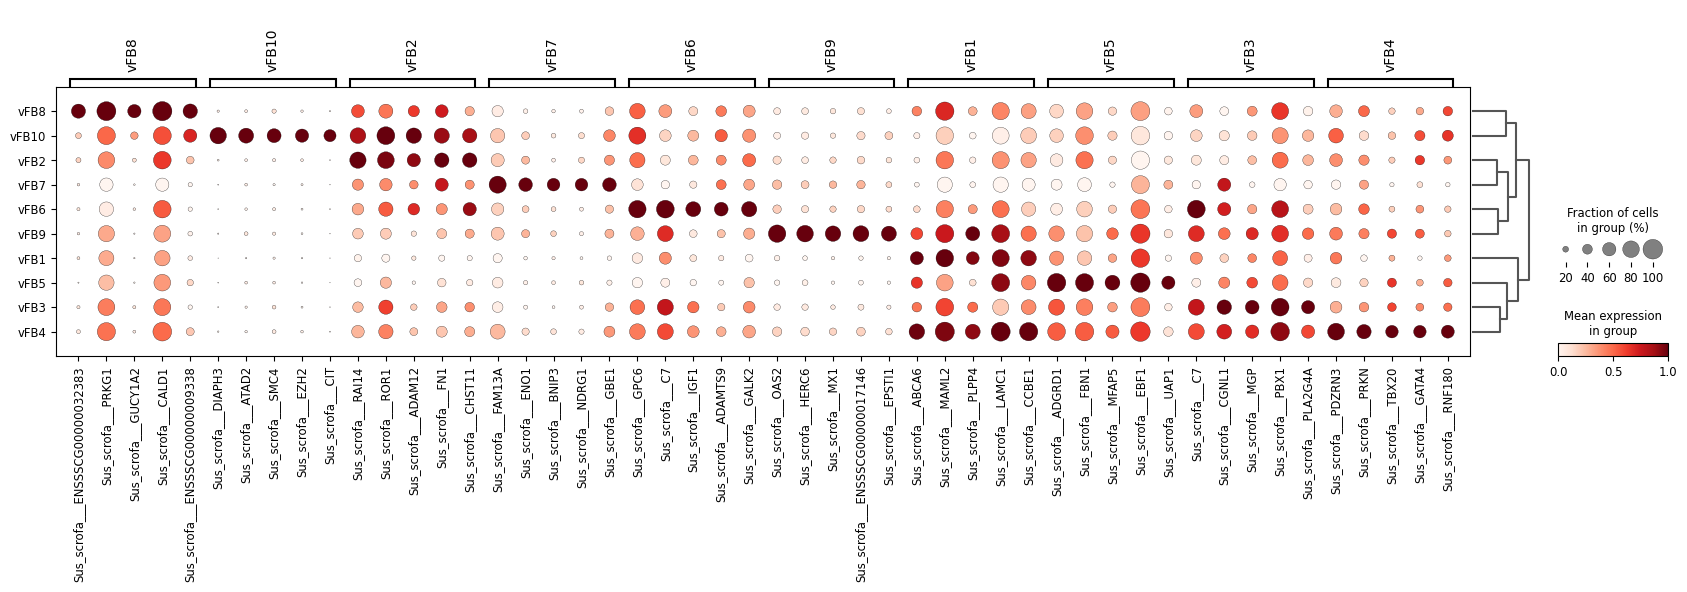

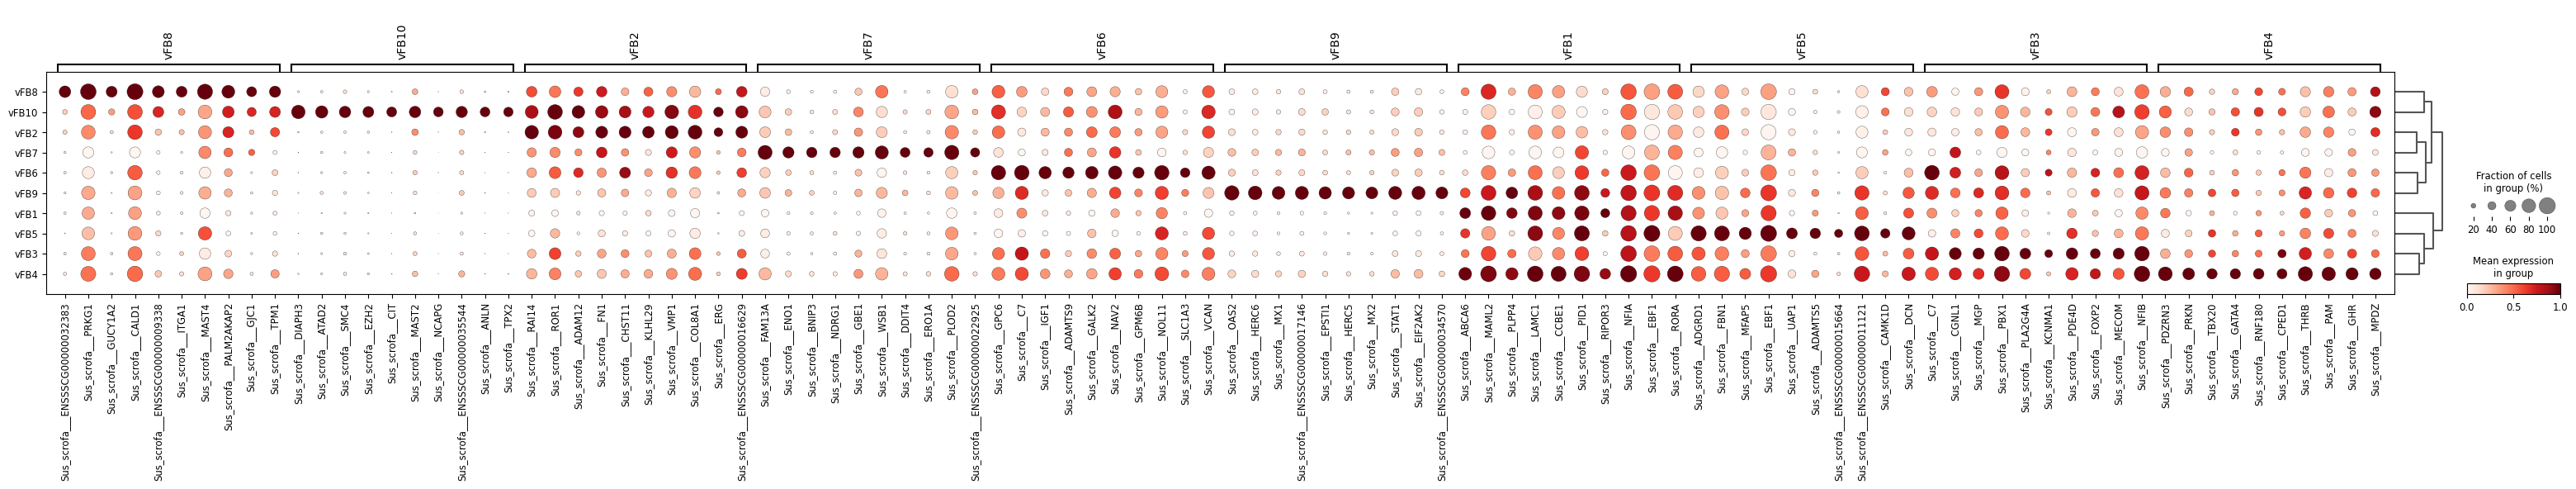

In [16]:
sc.pl.rank_genes_groups_dotplot(FB_adata, key="rank_genes_groups", n_genes=5, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )
sc.pl.rank_genes_groups_dotplot(FB_adata, key="rank_genes_groups", n_genes=10, standard_scale="var"
                                # , cmap="coolwarm", vmin= -1
                               )

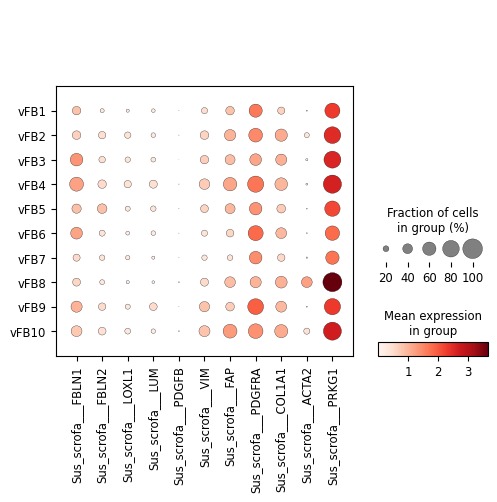

In [24]:
import scanpy as sc

genes = [
    # 'Sus_scrofa___COl1A1',
    # 'Sus_scrofa___COl1A2',
    # 'Sus_scrofa___COl5A1',
    'Sus_scrofa___FBLN1',     'Sus_scrofa___FBLN2',
    'Sus_scrofa___LOXL1',
    'Sus_scrofa___LUM',     'Sus_scrofa___PDGFB',
     'Sus_scrofa___VIM', 'Sus_scrofa___FAP', 'Sus_scrofa___PDGFRA', 'Sus_scrofa___COL1A1'
    , 'Sus_scrofa___ACTA2', 'Sus_scrofa___PRKG1'
]

# Make sure your cell type/cluster annotation column matches (e.g. 'leiden' or 'manual_annot')
sc.pl.dotplot(
    FB_adata, 
    var_names=genes, 
    groupby='cell_states', # e.g. 'leiden', 'cell_type', etc.
    # standard_scale='var'
)


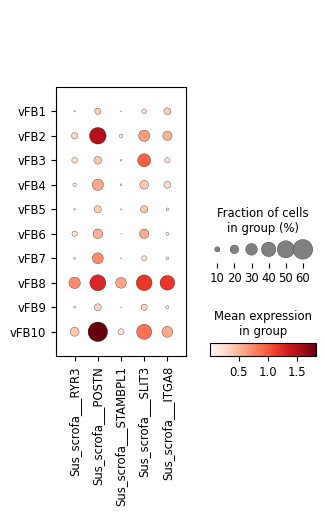

In [19]:
import scanpy as sc

genes = [
    # 'Sus_scrofa___COl1A1',
    # 'Sus_scrofa___COl1A2',
    # 'Sus_scrofa___COl5A1',
    'Sus_scrofa___RYR3',     'Sus_scrofa___POSTN',
    'Sus_scrofa___STAMBPL1',
    'Sus_scrofa___SLIT3',     'Sus_scrofa___ITGA8'
]

# Make sure your cell type/cluster annotation column matches (e.g. 'leiden' or 'manual_annot')
sc.pl.dotplot(
    FB_adata, 
    var_names=genes, 
    groupby='cell_states', # e.g. 'leiden', 'cell_type', etc.
    # standard_scale='var'
)


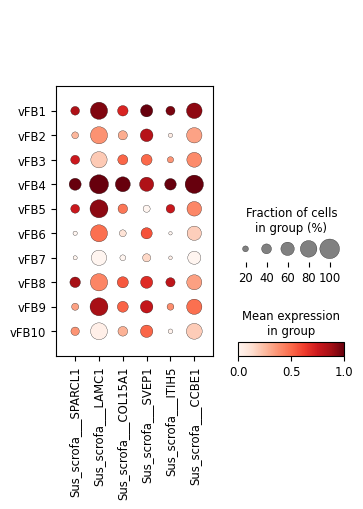

In [62]:
import scanpy as sc

genes = [
    'Sus_scrofa___SPARCL1',
    'Sus_scrofa___LAMC1',
    'Sus_scrofa___COL15A1',
    'Sus_scrofa___SVEP1',
    'Sus_scrofa___ITIH5',
    'Sus_scrofa___CCBE1'
]

# Make sure your cell type/cluster annotation column matches (e.g. 'leiden' or 'manual_annot')
sc.pl.dotplot(
    FB_adata, 
    var_names=genes, 
    groupby='cell_states', # e.g. 'leiden', 'cell_type', etc.
    standard_scale='var'
)


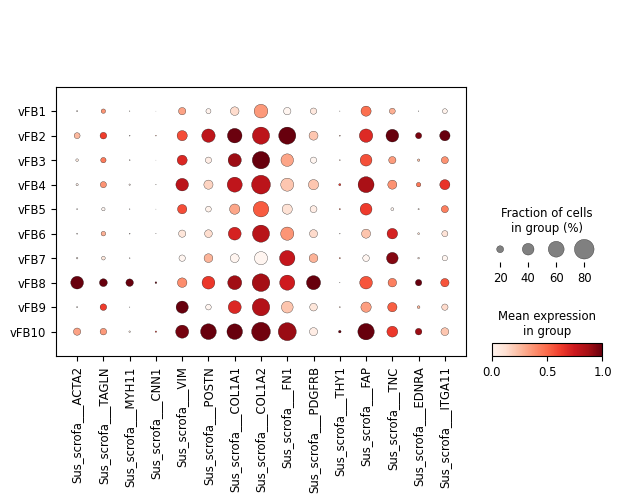

In [63]:
myofib_genes = [
    'Sus_scrofa___ACTA2',
    'Sus_scrofa___TAGLN',
    'Sus_scrofa___MYH11',
    'Sus_scrofa___CNN1',
    'Sus_scrofa___VIM',
    'Sus_scrofa___POSTN',
    'Sus_scrofa___COL1A1',
    'Sus_scrofa___COL1A2',
    'Sus_scrofa___FN1',
    'Sus_scrofa___PDGFRB',
    'Sus_scrofa___THY1',
    'Sus_scrofa___FAP',
    'Sus_scrofa___TNC',
    'Sus_scrofa___EDNRA',
    'Sus_scrofa___ITGA11'
]

sc.pl.dotplot(
    FB_adata, 
    var_names=myofib_genes, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)


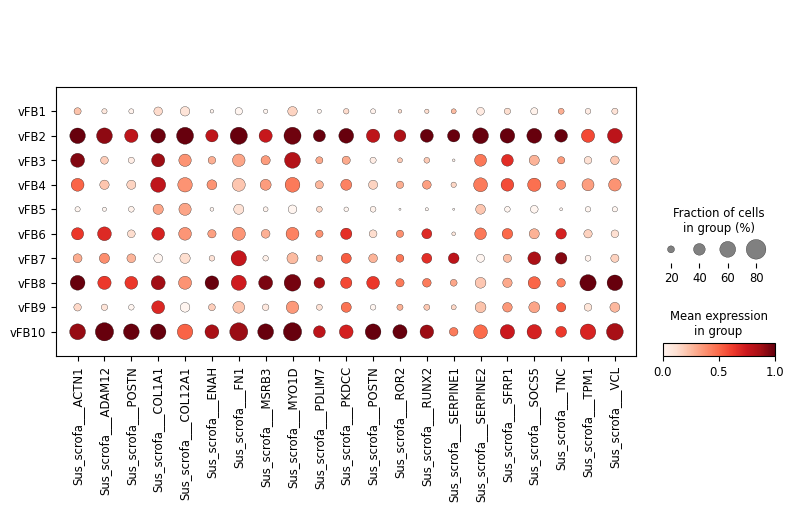

In [69]:
myofib_vfb2_deg = [
    "Sus_scrofa___ACTN1",
    "Sus_scrofa___ADAM12",
    "Sus_scrofa___POSTN",
    "Sus_scrofa___COL1A1",   

    "Sus_scrofa___COL12A1",
    "Sus_scrofa___ENAH",
    "Sus_scrofa___FN1",

    "Sus_scrofa___MSRB3",
    "Sus_scrofa___MYO1D",
    "Sus_scrofa___PDLIM7",
    "Sus_scrofa___PKDCC",
    "Sus_scrofa___POSTN",
    "Sus_scrofa___ROR2",

    "Sus_scrofa___RUNX2",
    "Sus_scrofa___SERPINE1",
    "Sus_scrofa___SERPINE2",
    "Sus_scrofa___SFRP1",
    "Sus_scrofa___SOCS5",
    "Sus_scrofa___TNC",
    "Sus_scrofa___TPM1",
    "Sus_scrofa___VCL",

]

sc.pl.dotplot(
    FB_adata,
    var_names=myofib_vfb2_deg,
    groupby="cell_states",  # replace with your cluster column, e.g. 'leiden'
    standard_scale='var'
)


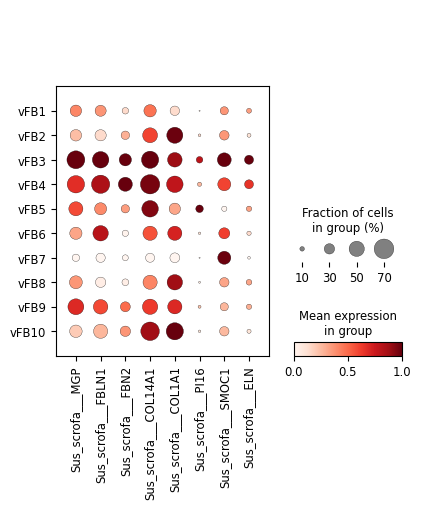

In [71]:
vfb3_deg = [
"Sus_scrofa___MGP",

"Sus_scrofa___FBLN1",

"Sus_scrofa___FBN2",

"Sus_scrofa___COL14A1",
    "Sus_scrofa___COL1A1",

"Sus_scrofa___PI16",

"Sus_scrofa___SMOC1",

"Sus_scrofa___ELN",

]

sc.pl.dotplot(
    FB_adata,
    var_names=vfb3_deg,
    groupby="cell_states",  # replace with your cluster column, e.g. 'leiden'
    standard_scale='var'
)


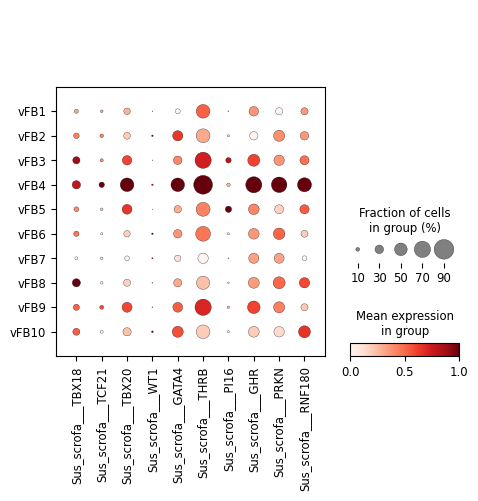

In [76]:
vfb4_deg = [

    
    
    "Sus_scrofa___TBX18",
    "Sus_scrofa___TCF21",
"Sus_scrofa___TBX20",
    "Sus_scrofa___WT1",


"Sus_scrofa___GATA4",

    "Sus_scrofa___THRB",

"Sus_scrofa___PI16",
    "Sus_scrofa___GHR",
"Sus_scrofa___PRKN",
    "Sus_scrofa___RNF180",

]

sc.pl.dotplot(
    FB_adata,
    var_names=vfb4_deg,
    groupby="cell_states",  # replace with your cluster column, e.g. 'leiden'
    standard_scale='var'
)


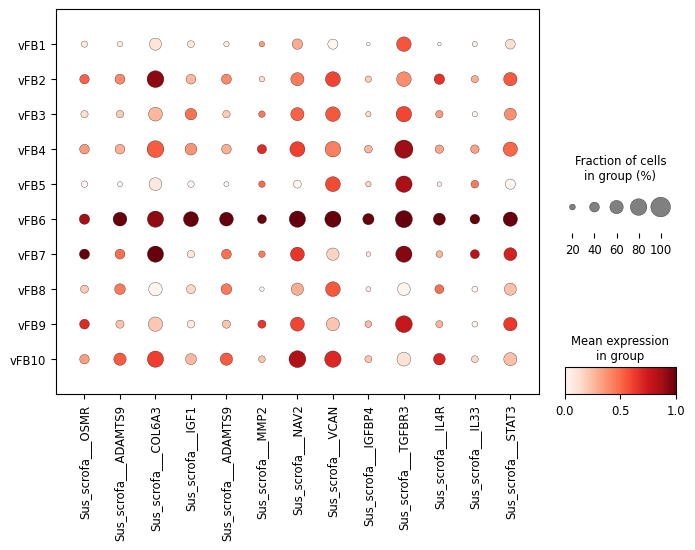

In [31]:
# List of the top marker genes (update names if you use different gene naming)
genes_vFB6 = [
    'Sus_scrofa___OSMR',    'Sus_scrofa___ADAMTS9',
    'Sus_scrofa___COL6A3',
    'Sus_scrofa___IGF1',
    'Sus_scrofa___ADAMTS9',
    'Sus_scrofa___MMP2',
    'Sus_scrofa___NAV2',
    'Sus_scrofa___VCAN',
    'Sus_scrofa___IGFBP4',
    'Sus_scrofa___TGFBR3',
    'Sus_scrofa___IL4R',
    'Sus_scrofa___IL33',
    'Sus_scrofa___STAT3'
]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB6,
    groupby='cell_states',    # or whatever is your cluster column
    color_map='Reds',
    figsize=(8,5),
    standard_scale = 'var'
)


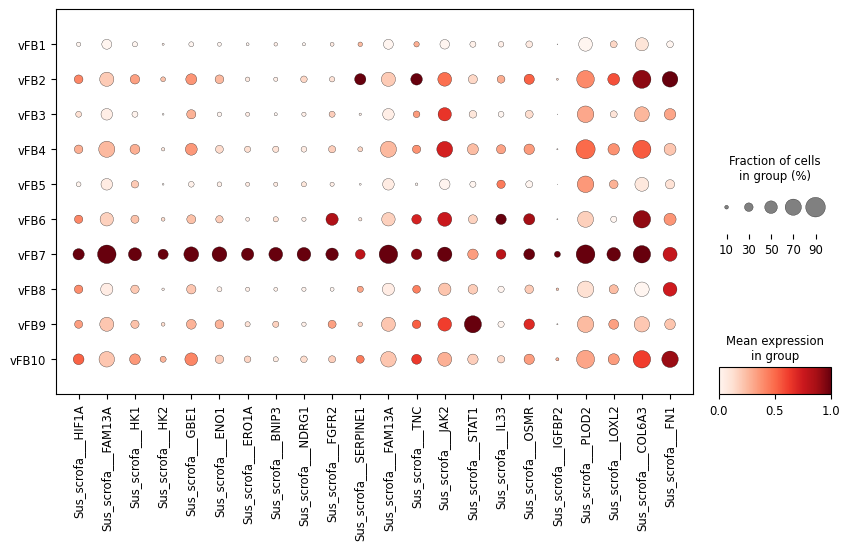

In [33]:
genes_vFB7 = [
       'Sus_scrofa___HIF1A', 'Sus_scrofa___FAM13A',     'Sus_scrofa___HK1',
    'Sus_scrofa___HK2',     'Sus_scrofa___GBE1',
    'Sus_scrofa___ENO1',    'Sus_scrofa___ERO1A',
    'Sus_scrofa___BNIP3',
    'Sus_scrofa___NDRG1',
    'Sus_scrofa___FGFR2',

    'Sus_scrofa___SERPINE1',
     'Sus_scrofa___FAM13A',

    'Sus_scrofa___TNC',

        'Sus_scrofa___JAK2',
            'Sus_scrofa___STAT1',
    'Sus_scrofa___IL33',
    'Sus_scrofa___OSMR',
    'Sus_scrofa___IGFBP2',
        'Sus_scrofa___PLOD2',
        'Sus_scrofa___LOXL2',
        'Sus_scrofa___COL6A3',
        'Sus_scrofa___FN1',
]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB7,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


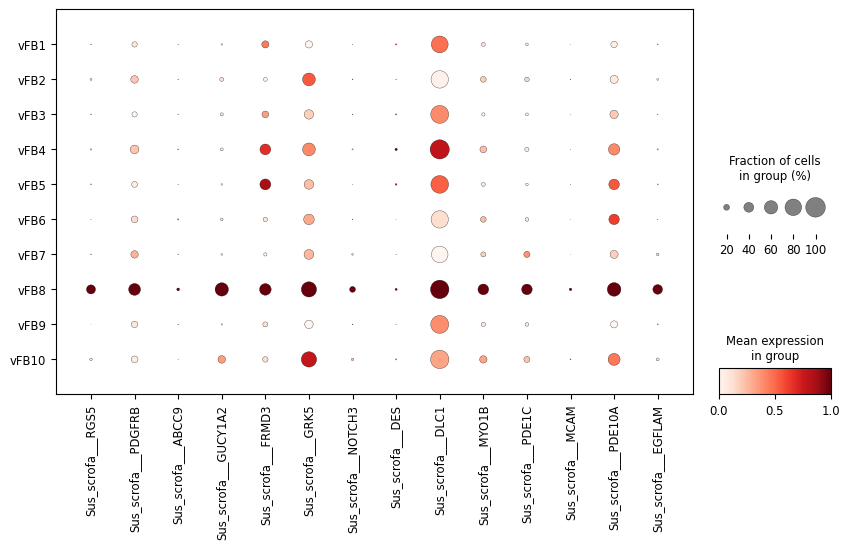

In [47]:
genes_vFB8 = [
       'Sus_scrofa___RGS5', 'Sus_scrofa___PDGFRB',     'Sus_scrofa___ABCC9','Sus_scrofa___GUCY1A2', 'Sus_scrofa___FRMD3','Sus_scrofa___GRK5',
    'Sus_scrofa___NOTCH3',      'Sus_scrofa___DES',     'Sus_scrofa___DLC1',

    
    'Sus_scrofa___MYO1B',     'Sus_scrofa___PDE1C',

    'Sus_scrofa___MCAM',
    'Sus_scrofa___PDE10A',
 'Sus_scrofa___EGFLAM',  

]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB8,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


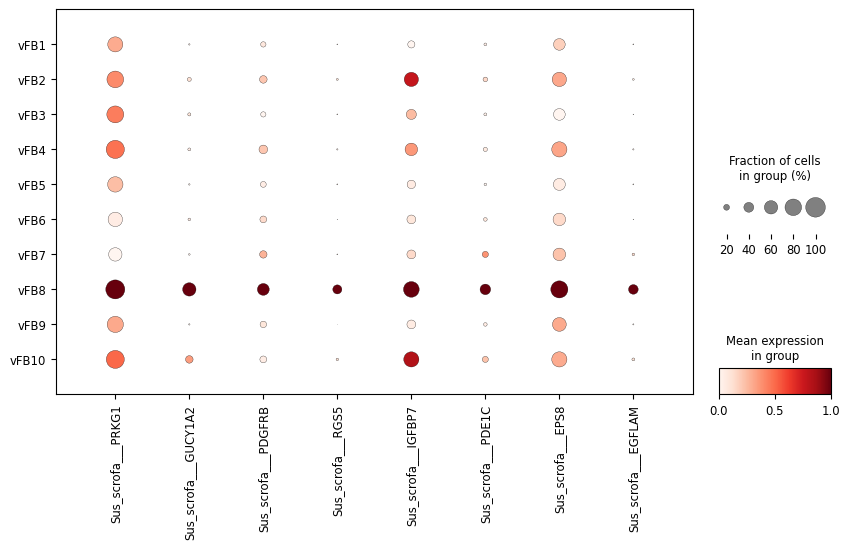

In [25]:
pericyte_discriminators = [
    'Sus_scrofa___PRKG1',    # Most specific for pericytes
    'Sus_scrofa___GUCY1A2',  # Strong pericyte
    'Sus_scrofa___PDGFRB',   # Pericyte, but also SMC
    'Sus_scrofa___RGS5',     # Pericyte, also SMC
    'Sus_scrofa___IGFBP7',   # Pericyte > SMC > FB

     'Sus_scrofa___PDE1C',
    'Sus_scrofa___EPS8',
    'Sus_scrofa___EGFLAM'
]

sc.pl.dotplot(
    FB_adata,
    var_names=pericyte_discriminators,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


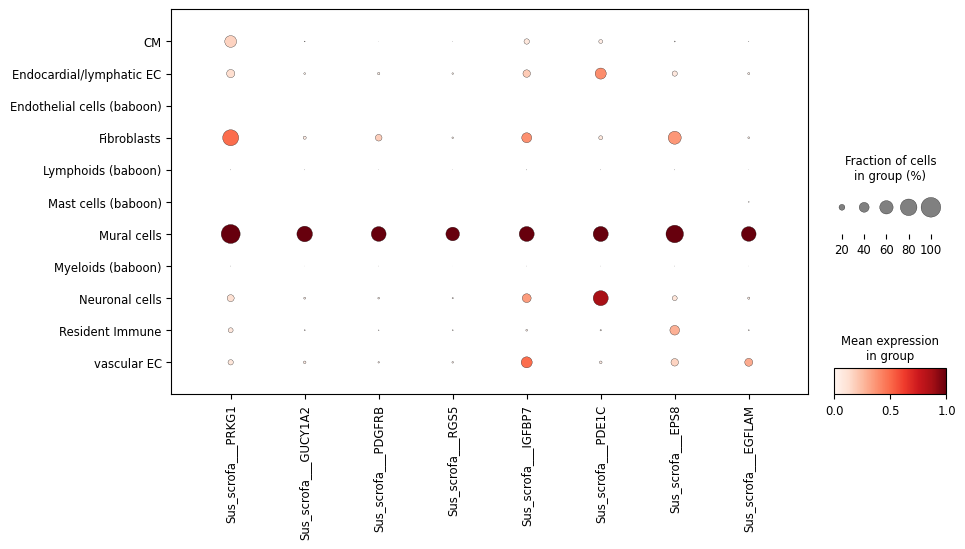

In [24]:
pericyte_discriminators = [
    'Sus_scrofa___PRKG1',    # Most specific for pericytes
    'Sus_scrofa___GUCY1A2',  # Strong pericyte
    'Sus_scrofa___PDGFRB',   # Pericyte, but also SMC
    'Sus_scrofa___RGS5',     # Pericyte, also SMC
    'Sus_scrofa___IGFBP7',   # Pericyte > SMC > FB

     'Sus_scrofa___PDE1C',
    'Sus_scrofa___EPS8',
    'Sus_scrofa___EGFLAM'
]

sc.pl.dotplot(
    new_adata,
    var_names=pericyte_discriminators,
    groupby='cell_type',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


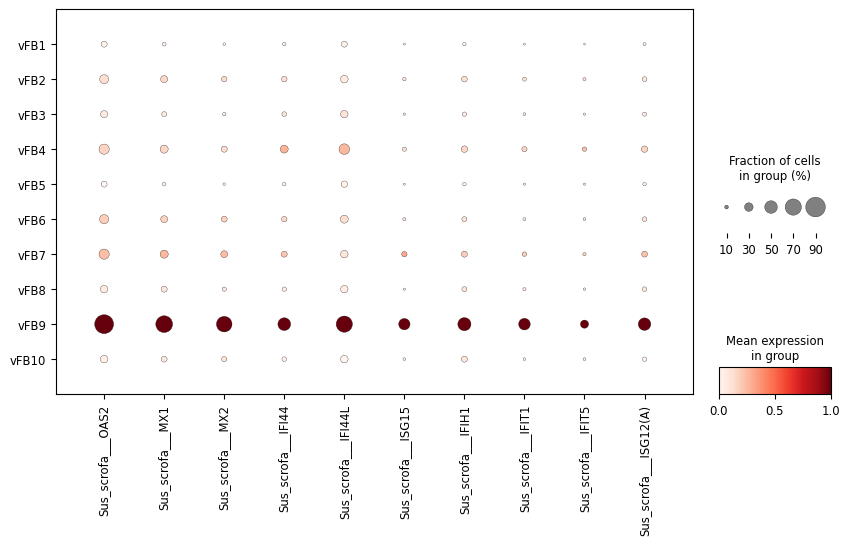

In [49]:
genes_vFB8 = [
       'Sus_scrofa___OAS2', 'Sus_scrofa___MX1',     'Sus_scrofa___MX2','Sus_scrofa___IFI44', 'Sus_scrofa___IFI44L','Sus_scrofa___ISG15',
    'Sus_scrofa___IFIH1',      'Sus_scrofa___IFIT1',     'Sus_scrofa___IFIT5',

   'Sus_scrofa___ISG12(A)',

]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB8,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


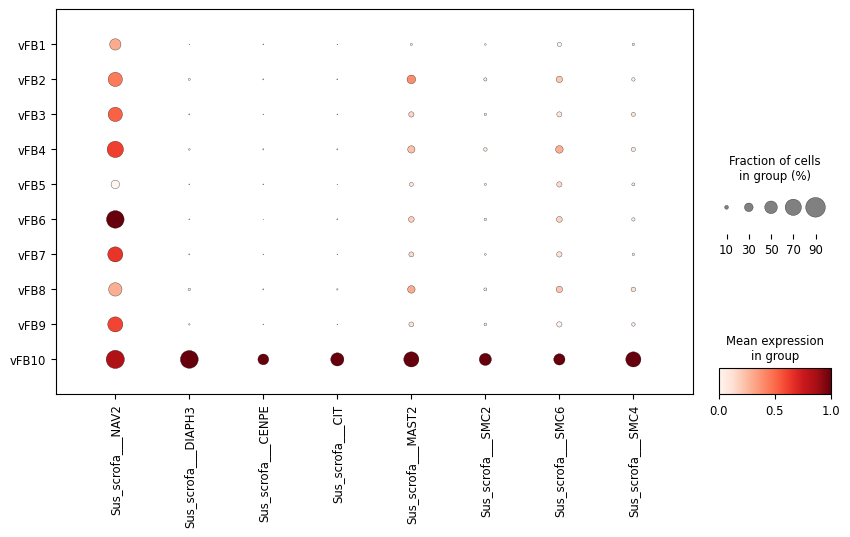

In [55]:
genes_vFB10 = [
       'Sus_scrofa___NAV2', 'Sus_scrofa___DIAPH3', 'Sus_scrofa___CENPE',    'Sus_scrofa___CIT', 'Sus_scrofa___MAST2',
'Sus_scrofa___SMC2','Sus_scrofa___SMC6','Sus_scrofa___SMC4',


]

sc.pl.dotplot(
    FB_adata,
    var_names=genes_vFB10,
    groupby='cell_states',    # or your cluster column
    color_map='Reds',
    figsize=(10,5),
    standard_scale = 'var'
)


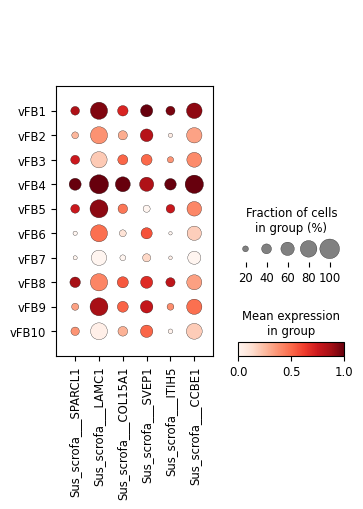

In [57]:
genes = [
    'Sus_scrofa___SPARCL1',
    'Sus_scrofa___LAMC1',
    'Sus_scrofa___COL15A1',
    'Sus_scrofa___SVEP1',
    'Sus_scrofa___ITIH5',
    'Sus_scrofa___CCBE1'
]

# Make sure your cell type/cluster annotation column matches (e.g. 'leiden' or 'manual_annot')
sc.pl.dotplot(
    FB_adata, 
    var_names=genes, 
    groupby='cell_states', # e.g. 'leiden', 'cell_type', etc.
    standard_scale='var'
)


In [4]:
pericyte_markers = [
'Sus_scrofa___ENSSSCG00000032383', 'Sus_scrofa___PRKG1', 'Sus_scrofa___GUCY1A2', 'Sus_scrofa___CALD1', 'Sus_scrofa___ENSSSCG00000009338', 'Sus_scrofa___ITGA1', 'Sus_scrofa___MAST4', 'Sus_scrofa___PALM2AKAP2', 'Sus_scrofa___GJC1', 'Sus_scrofa___TPM1',
'Sus_scrofa___ACTA2', 'Sus_scrofa___IRAG1', 'Sus_scrofa___IGFBP7', 'Sus_scrofa___RBPMS', 'Sus_scrofa___PLCL1', 'Sus_scrofa___ENSSSCG00000000145', 'Sus_scrofa___EPS8', 'Sus_scrofa___EGFLAM', 'Sus_scrofa___GRK5', 'Sus_scrofa___LPP',
'Sus_scrofa___RAPGEF2', 'Sus_scrofa___VCL', 'Sus_scrofa___ENSSSCG00000027725', 'Sus_scrofa___CACNB2', 'Sus_scrofa___PDE1C', 'Sus_scrofa___PPP1R12A', 'Sus_scrofa___KCNAB1', 'Sus_scrofa___RGS5', 'Sus_scrofa___SYNPO2', 'Sus_scrofa___STK38L',
'Sus_scrofa___FERMT2', 'Sus_scrofa___GRM7', 'Sus_scrofa___PAWR', 'Sus_scrofa___PDE10A', 'Sus_scrofa___PELI2', 'Sus_scrofa___ENAH', 'Sus_scrofa___MYO1B', 'Sus_scrofa___NRP1', 'Sus_scrofa___C3orf70', 'Sus_scrofa___MSRB3',
'Sus_scrofa___PDGFRB', 'Sus_scrofa___TBC1D1', 'Sus_scrofa___MAGI1', 'Sus_scrofa___PDLIM5', 'Sus_scrofa___CLIC4', 'Sus_scrofa___FRMD4A', 'Sus_scrofa___P3H2', 'Sus_scrofa___ITGA8', 'Sus_scrofa___RASAL2', 'Sus_scrofa___ATXN1',
'Sus_scrofa___ENSSSCG00000049691', 'Sus_scrofa___PDE3A', 'Sus_scrofa___MYO1E', 'Sus_scrofa___FARP1', 'Sus_scrofa___SEPTIN11', 'Sus_scrofa___SLIT3', 'Sus_scrofa___MAP1B', 'Sus_scrofa___ESYT2', 'Sus_scrofa___MEF2C', 'Sus_scrofa___ANO1',
'Sus_scrofa___SORBS1', 'Sus_scrofa___FRMD3', 'Sus_scrofa___CACNA2D1', 'Sus_scrofa___GUCY1B1', 'Sus_scrofa___CDH13', 'Sus_scrofa___DAAM2', 'Sus_scrofa___DMD', 'Sus_scrofa___ENSSSCG00000036812', 'Sus_scrofa___TNS1', 'Sus_scrofa___ENSSSCG00000039009',
'Sus_scrofa___FLNA', 'Sus_scrofa___MRTFA', 'Sus_scrofa___STAMBPL1', 'Sus_scrofa___MYO1D', 'Sus_scrofa___ITGB1', 'Sus_scrofa___CYTH3', 'Sus_scrofa___DLC1', 'Sus_scrofa___IQGAP1', 'Sus_scrofa___PHLDB2', 'Sus_scrofa___RYR3',
'Sus_scrofa___NCALD', 'Sus_scrofa___TNIK', 'Sus_scrofa___POSTN', 'Sus_scrofa___PGM5', 'Sus_scrofa___LHFPL6', 'Sus_scrofa___ADAMTS12', 'Sus_scrofa___FILIP1', 'Sus_scrofa___TANC1', 'Sus_scrofa___ARHGAP24', 'Sus_scrofa___CUX1',
'Sus_scrofa___ACTN1', 'Sus_scrofa___MACF1', 'Sus_scrofa___PTPRK', 'Sus_scrofa___FN1', 'Sus_scrofa___ARHGAP26', 'Sus_scrofa___AOPEP', 'Sus_scrofa___FAM13C', 'Sus_scrofa___SEMA5A', 'Sus_scrofa___ARHGAP10', 'Sus_scrofa___THSD7A'
]


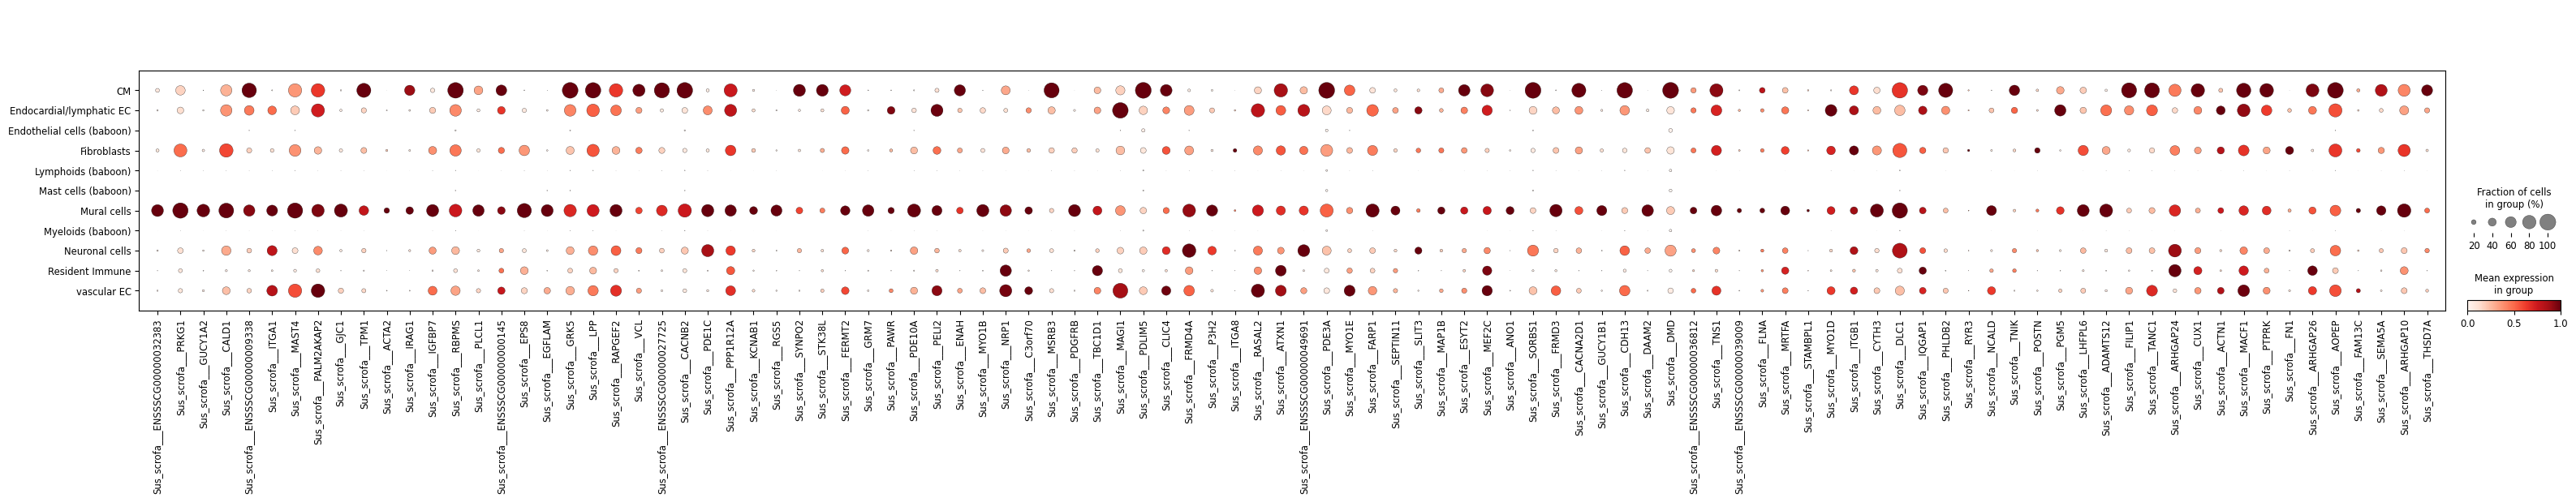

In [12]:
sc.pl.dotplot(
    new_adata, 
    var_names=pericyte_markers, 
    groupby='cell_type', # e.g. 'leiden', 'cell_type', etc.
    standard_scale='var'
)

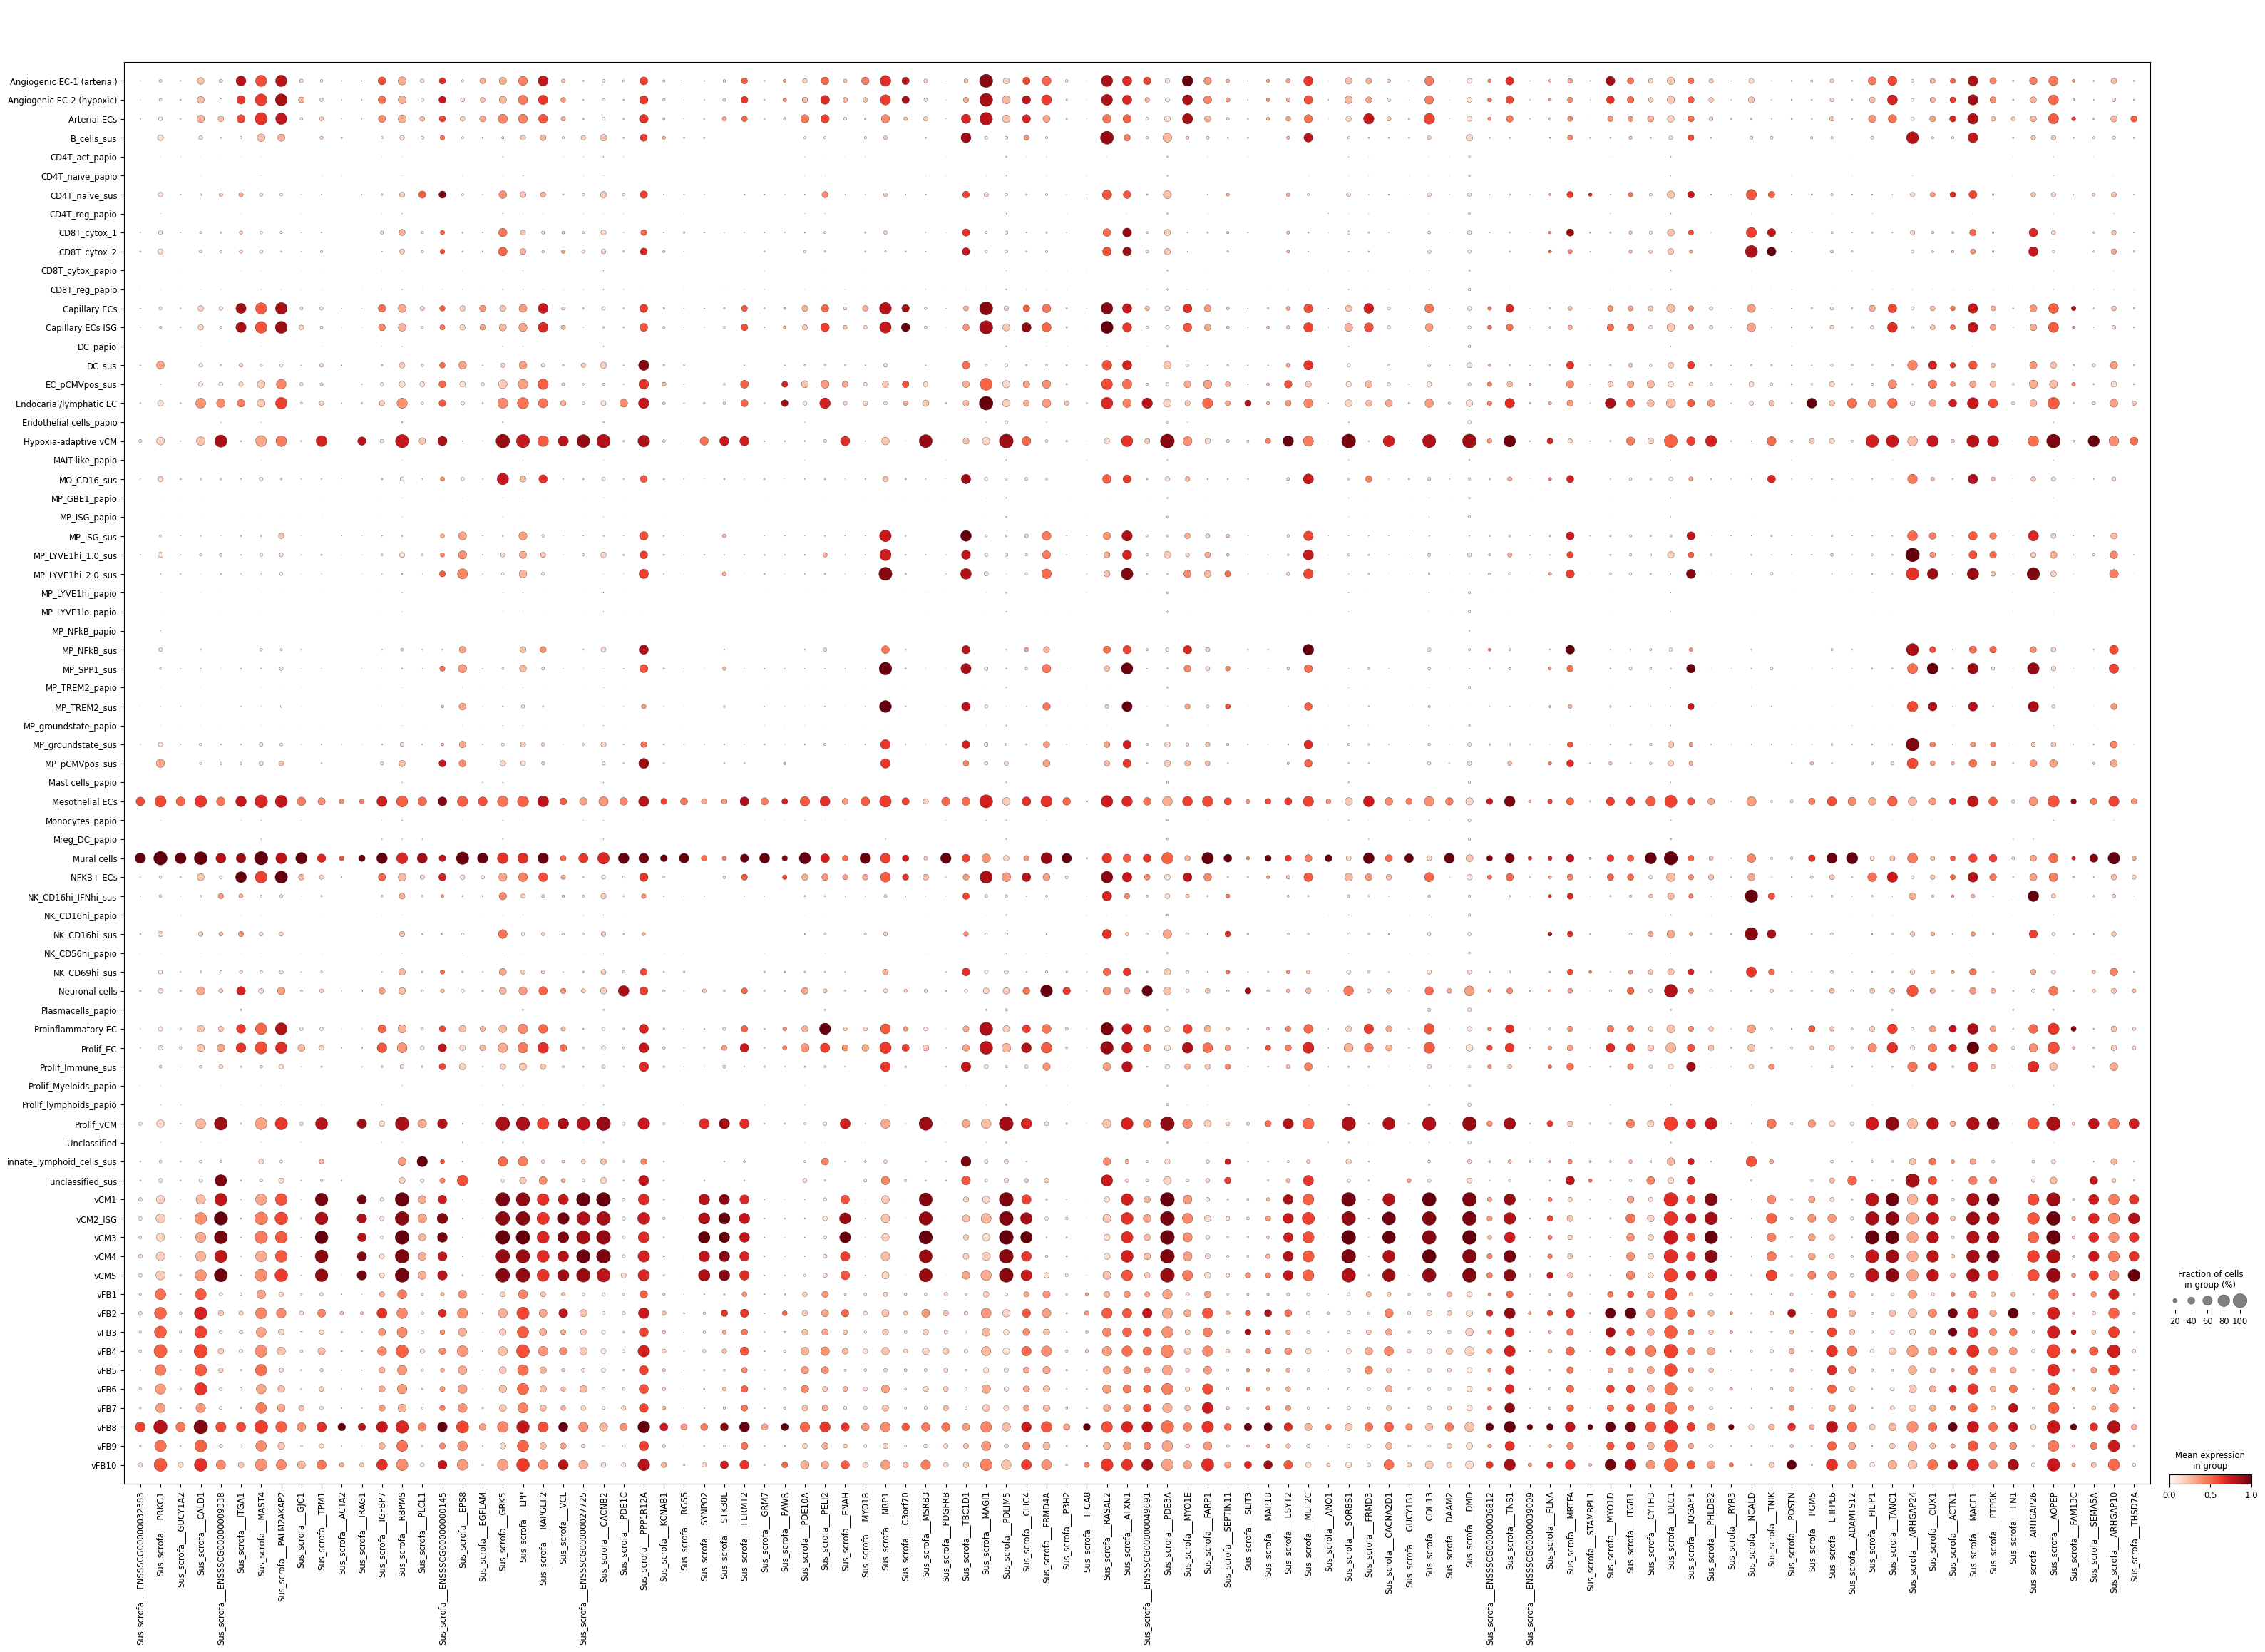

In [13]:
sc.pl.dotplot(
    new_adata, 
    var_names=pericyte_markers, 
    groupby='cell_states', # e.g. 'leiden', 'cell_type', etc.
    standard_scale='var'
)

Using 100 markers (of 100)


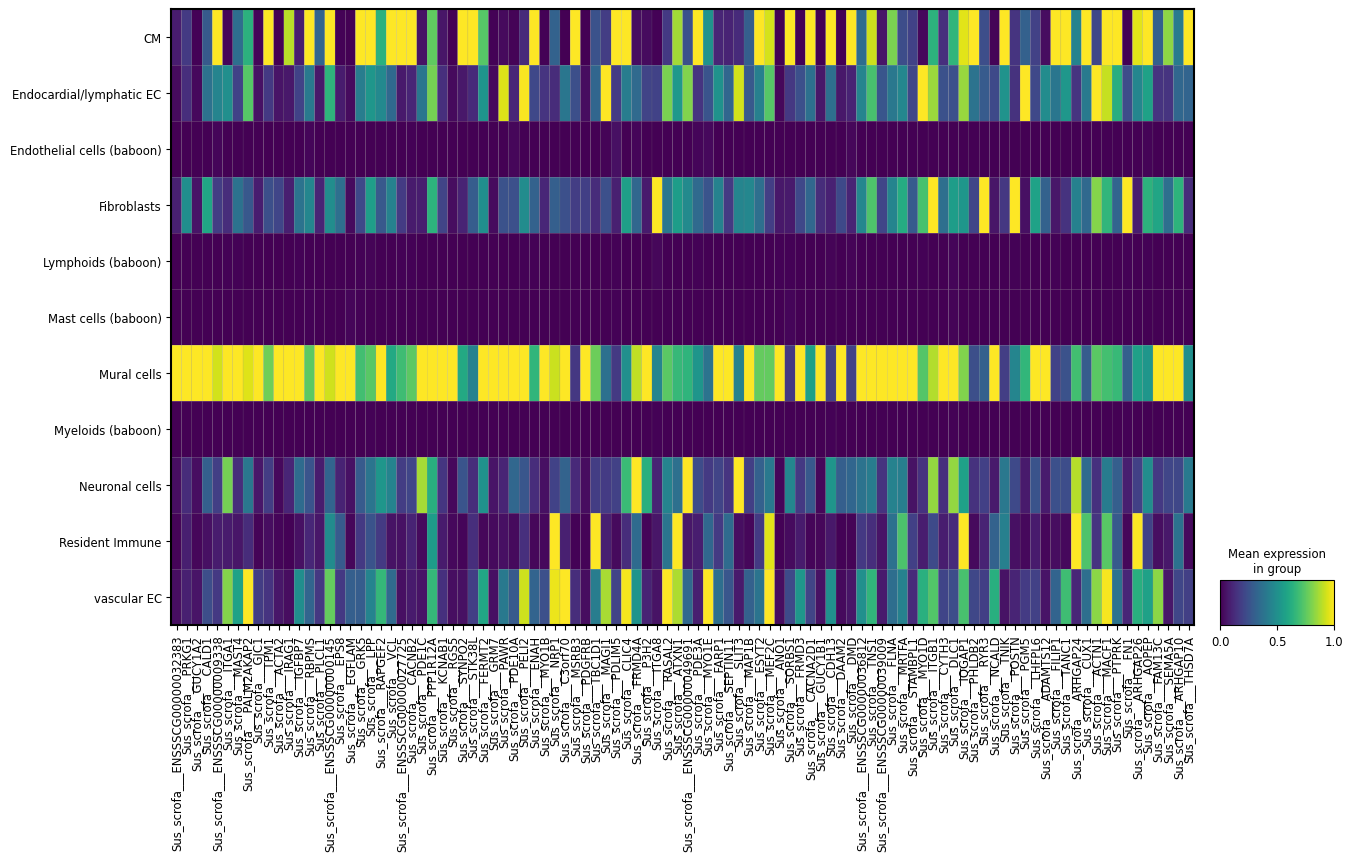

In [19]:
present_pericyte_markers = [g for g in pericyte_markers if g in global_raw.var_names]
print(f"Using {len(present_pericyte_markers)} markers (of {len(pericyte_markers)})")

sc.pl.matrixplot(
    new_adata,
    var_names=present_pericyte_markers,
    groupby="cell_type",
    # use_raw=True,
    standard_scale='var',
    figsize=(15, 8),
    show=True
)


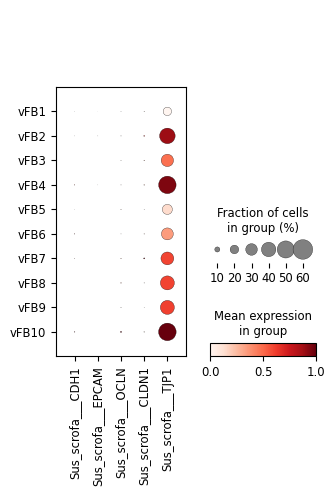

In [26]:
DOWN_EMT_genes = [
    'Sus_scrofa___CDH1',
    'Sus_scrofa___EPCAM',
    'Sus_scrofa___OCLN',
    'Sus_scrofa___CLDN1',
    'Sus_scrofa___TJP1',

]

sc.pl.dotplot(
    FB_adata, 
    var_names=DOWN_EMT_genes, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)


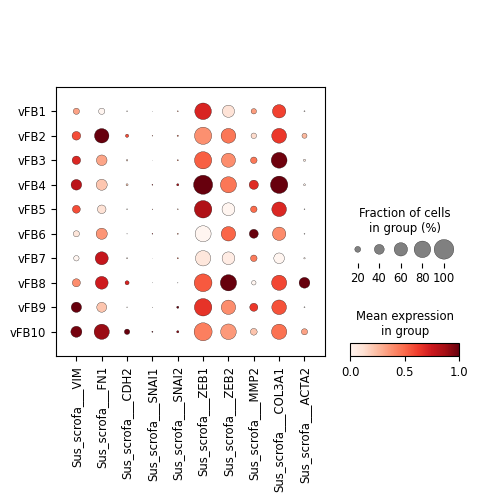

In [29]:
UP_EMT_genes = [
    'Sus_scrofa___VIM',
    'Sus_scrofa___FN1',
    'Sus_scrofa___CDH2',
    'Sus_scrofa___SNAI1',
    'Sus_scrofa___SNAI2',


        'Sus_scrofa___ZEB1',
    'Sus_scrofa___ZEB2',
    'Sus_scrofa___MMP2',
    'Sus_scrofa___COL3A1',
    'Sus_scrofa___ACTA2',

]

sc.pl.dotplot(
    FB_adata, 
    var_names=UP_EMT_genes, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)


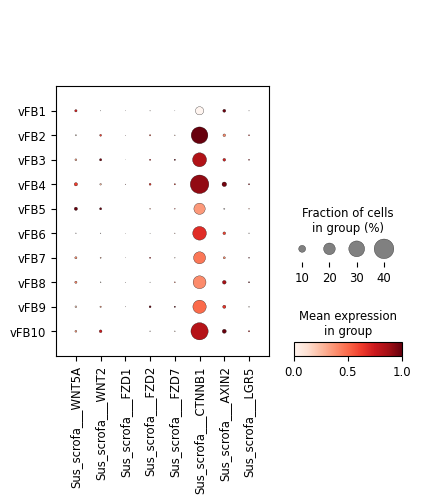

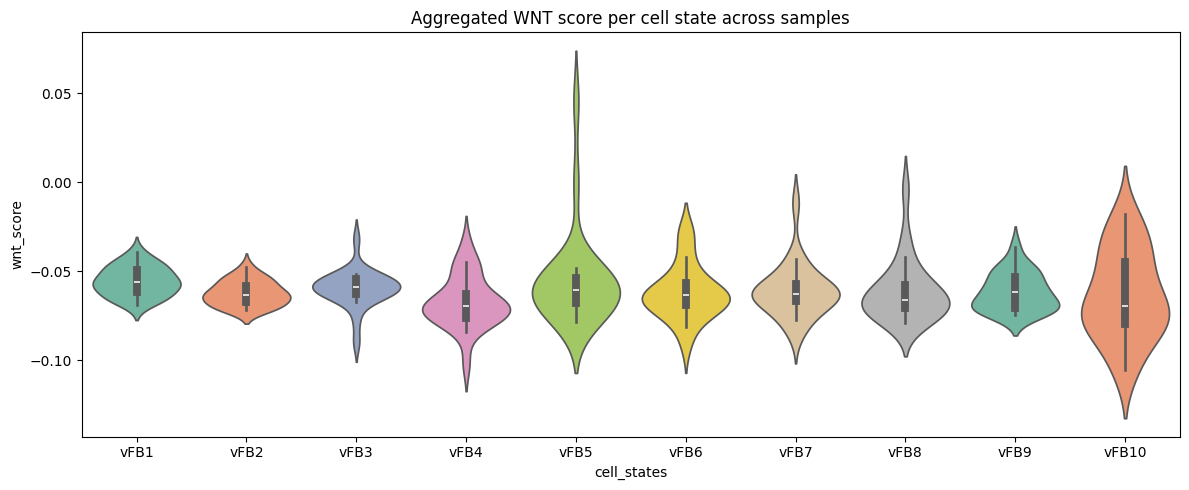

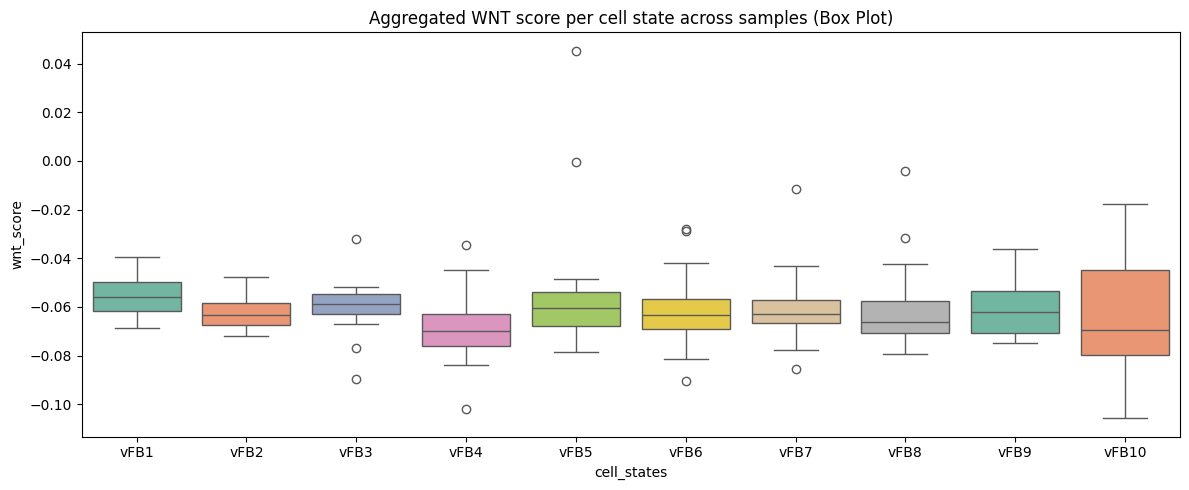

In [80]:
wnt_markers = [
    'Sus_scrofa___WNT5A', 'Sus_scrofa___WNT2', 'Sus_scrofa___FZD1',
    'Sus_scrofa___FZD2', 'Sus_scrofa___FZD7', 'Sus_scrofa___CTNNB1',
    'Sus_scrofa___AXIN2', 'Sus_scrofa___LGR5'
]

sc.pl.dotplot(
    global_FB_adata, 
    var_names=wnt_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=wnt_markers, score_name='wnt_score')


scores_df = global_FB_adata.obs[['wnt_score', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['wnt_score'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='wnt_score',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated WNT score per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='wnt_score',
    palette='Set2'
)
plt.title('Aggregated WNT score per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()


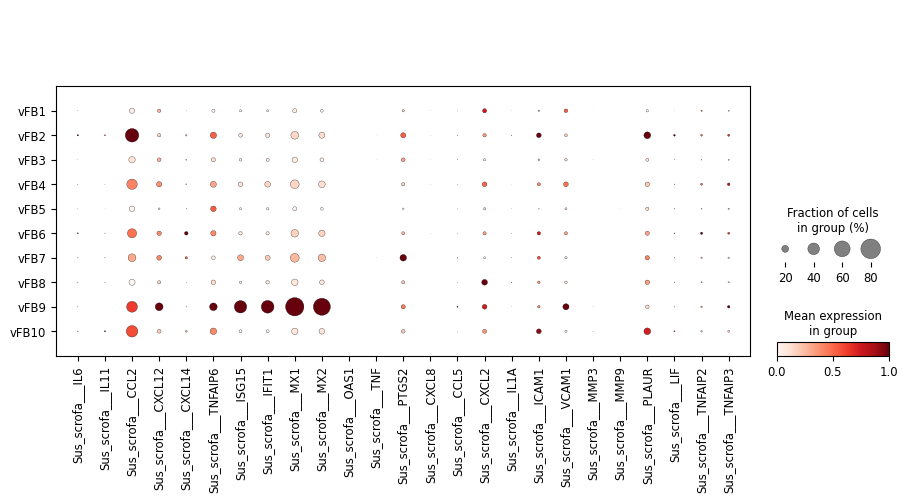

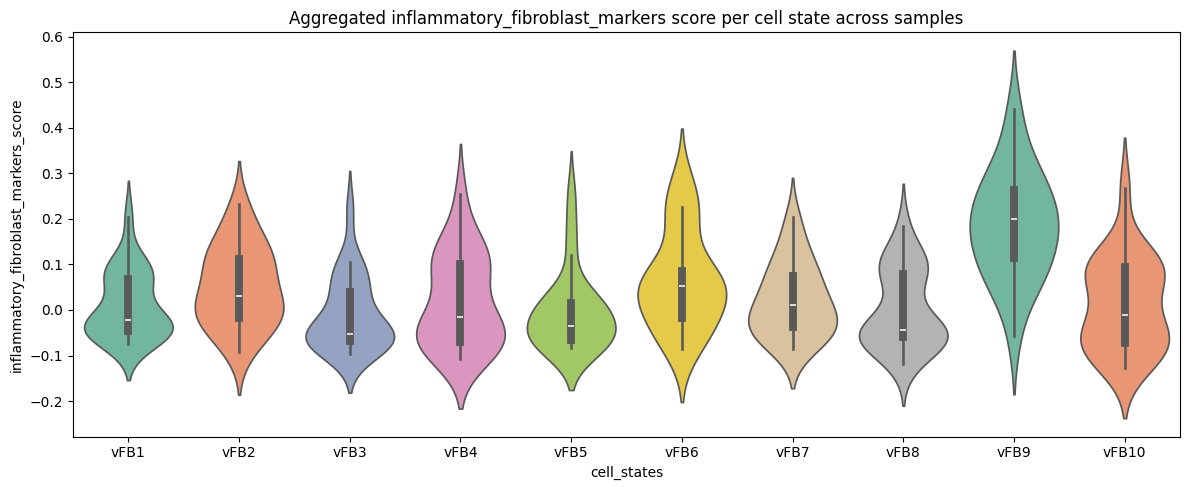

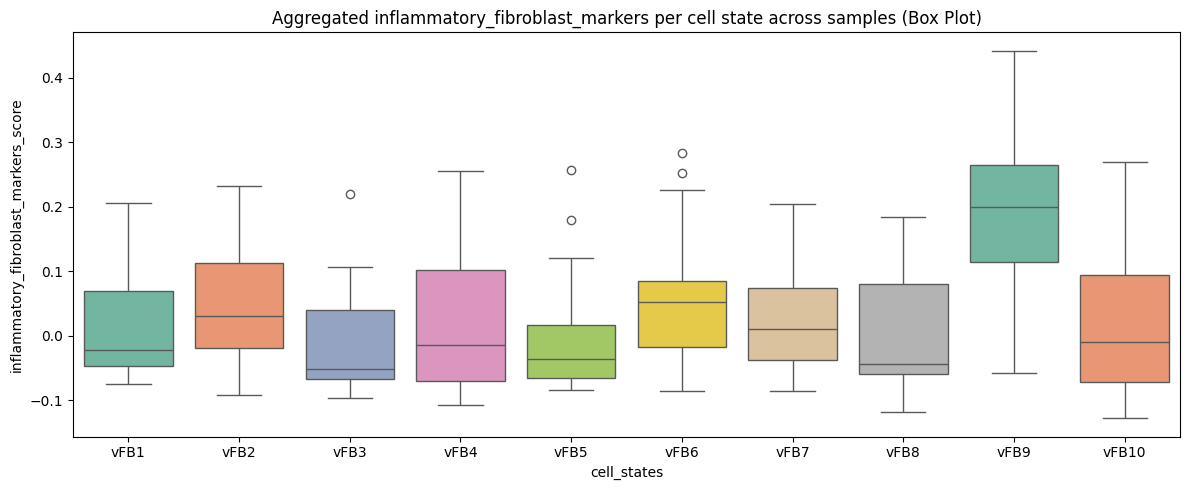

In [81]:
inflammatory_fibroblast_markers = [
    'Sus_scrofa___IL6', 'Sus_scrofa___IL11', 'Sus_scrofa___CCL2',
    'Sus_scrofa___CXCL12', 'Sus_scrofa___CXCL14', 
    'Sus_scrofa___TNFAIP6', 'Sus_scrofa___ISG15',
    'Sus_scrofa___IFIT1', 'Sus_scrofa___MX1', 'Sus_scrofa___MX2',
    'Sus_scrofa___OAS1',
 'Sus_scrofa___TNF', 'Sus_scrofa___PTGS2', 'Sus_scrofa___CXCL8',
    'Sus_scrofa___CCL5', 'Sus_scrofa___CXCL2', 'Sus_scrofa___IL1A', 'Sus_scrofa___ICAM1',
    'Sus_scrofa___VCAM1', 'Sus_scrofa___MMP3', 'Sus_scrofa___MMP9', 'Sus_scrofa___PLAUR',
'Sus_scrofa___LIF', 'Sus_scrofa___TNFAIP2', 'Sus_scrofa___TNFAIP3'

]


sc.pl.dotplot(
    raw_FB_adata, 
    var_names=inflammatory_fibroblast_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(raw_FB_adata, gene_list=inflammatory_fibroblast_markers, score_name='inflammatory_fibroblast_markers_score')


scores_df = raw_FB_adata.obs[['inflammatory_fibroblast_markers_score', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['inflammatory_fibroblast_markers_score'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='inflammatory_fibroblast_markers_score',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated inflammatory_fibroblast_markers score per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='inflammatory_fibroblast_markers_score',
    palette='Set2'
)
plt.title('Aggregated inflammatory_fibroblast_markers per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()


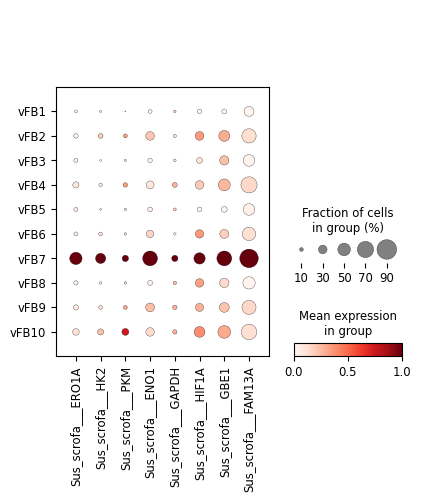

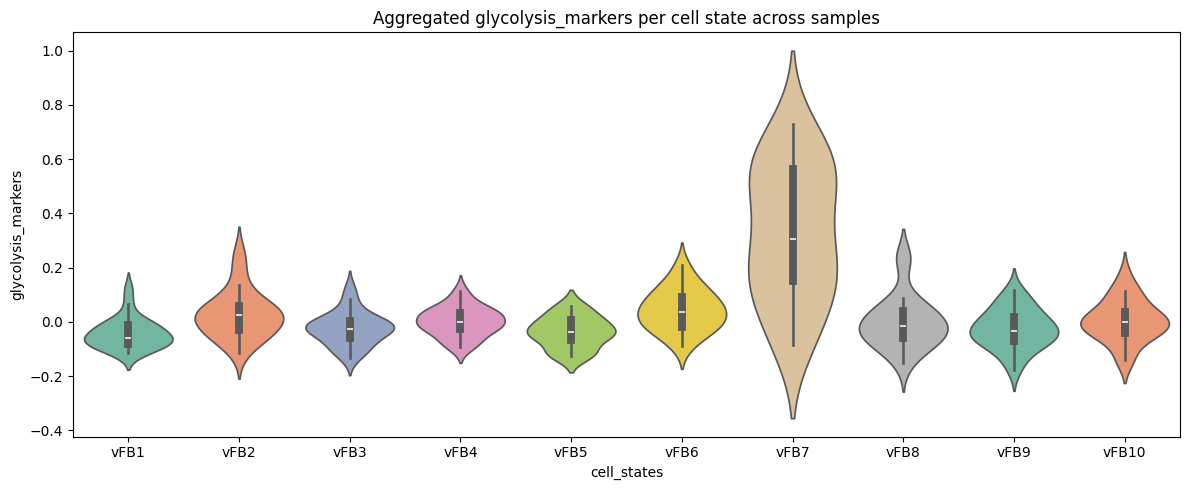

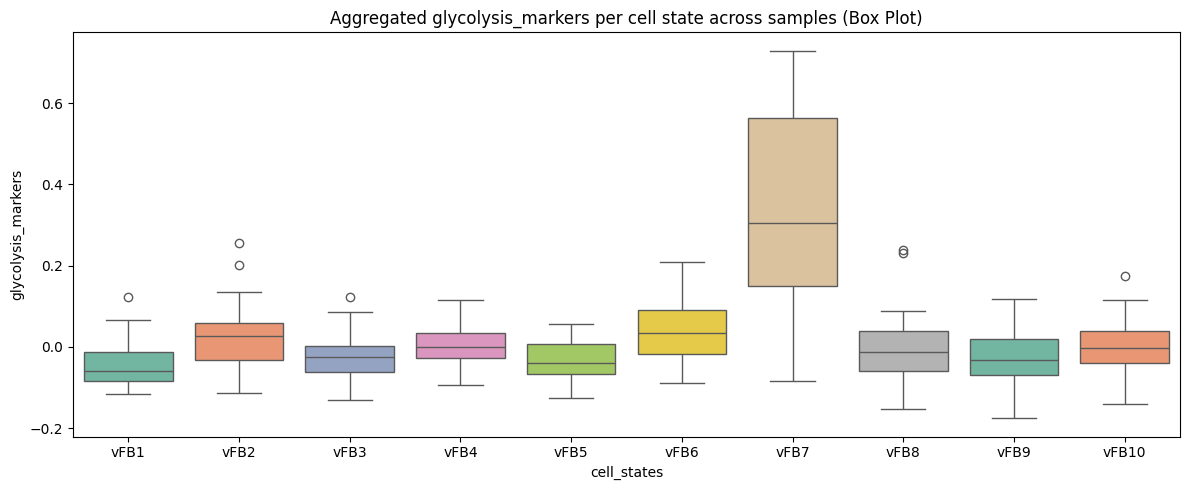

In [82]:
glycolysis_markers = [
    'Sus_scrofa___ERO1A', 'Sus_scrofa___HK2', 'Sus_scrofa___PKM',
    'Sus_scrofa___ENO1', 'Sus_scrofa___GAPDH',  'Sus_scrofa___HIF1A' ,  'Sus_scrofa___GBE1' ,  'Sus_scrofa___FAM13A' 
]

sc.pl.dotplot(
    global_FB_adata, 
    var_names=glycolysis_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=glycolysis_markers, score_name='glycolysis_markers')


scores_df = global_FB_adata.obs[['glycolysis_markers', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['glycolysis_markers'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='glycolysis_markers',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated glycolysis_markers per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='glycolysis_markers',
    palette='Set2'
)
plt.title('Aggregated glycolysis_markers per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()


In [66]:
# OSM: LIFR
# IL6ST
# OSMR
# PTPN11
# TYK2
# PTK2B
# GRB2
# EGR1
# LDLR
# VEGFA
# HIF1A
# FOS
# JUNB
# JUND
# CCL2
# MMP1
# RELA
# CYR61

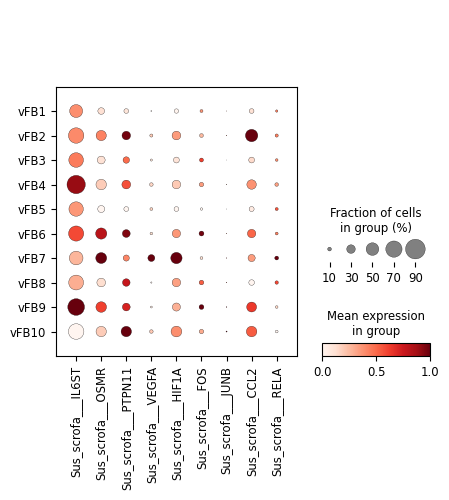

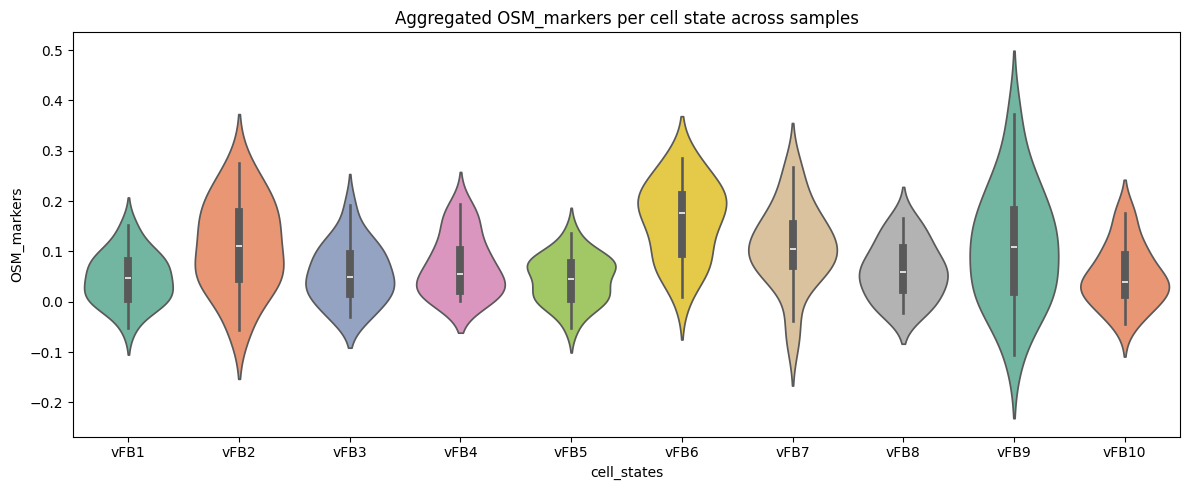

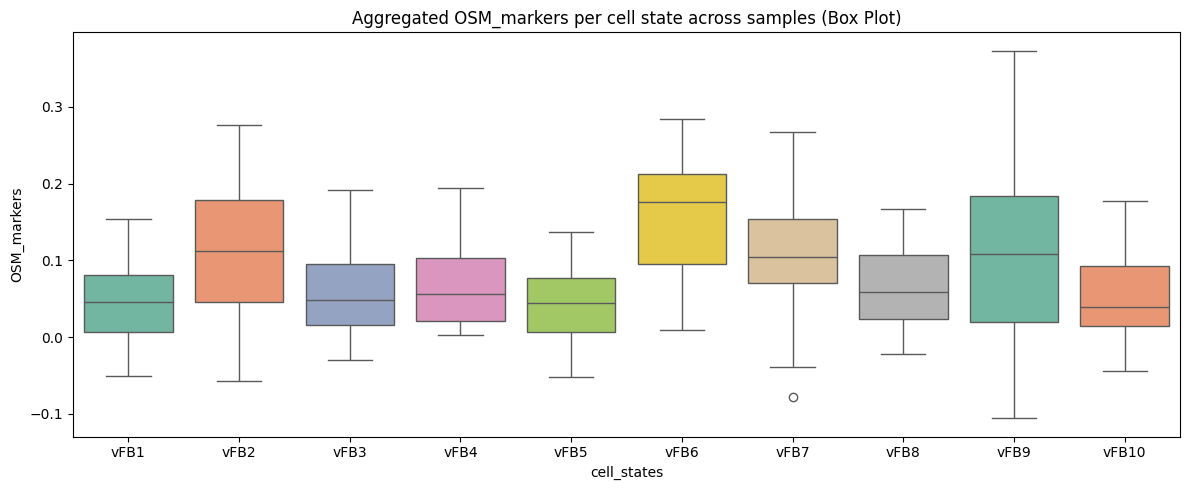

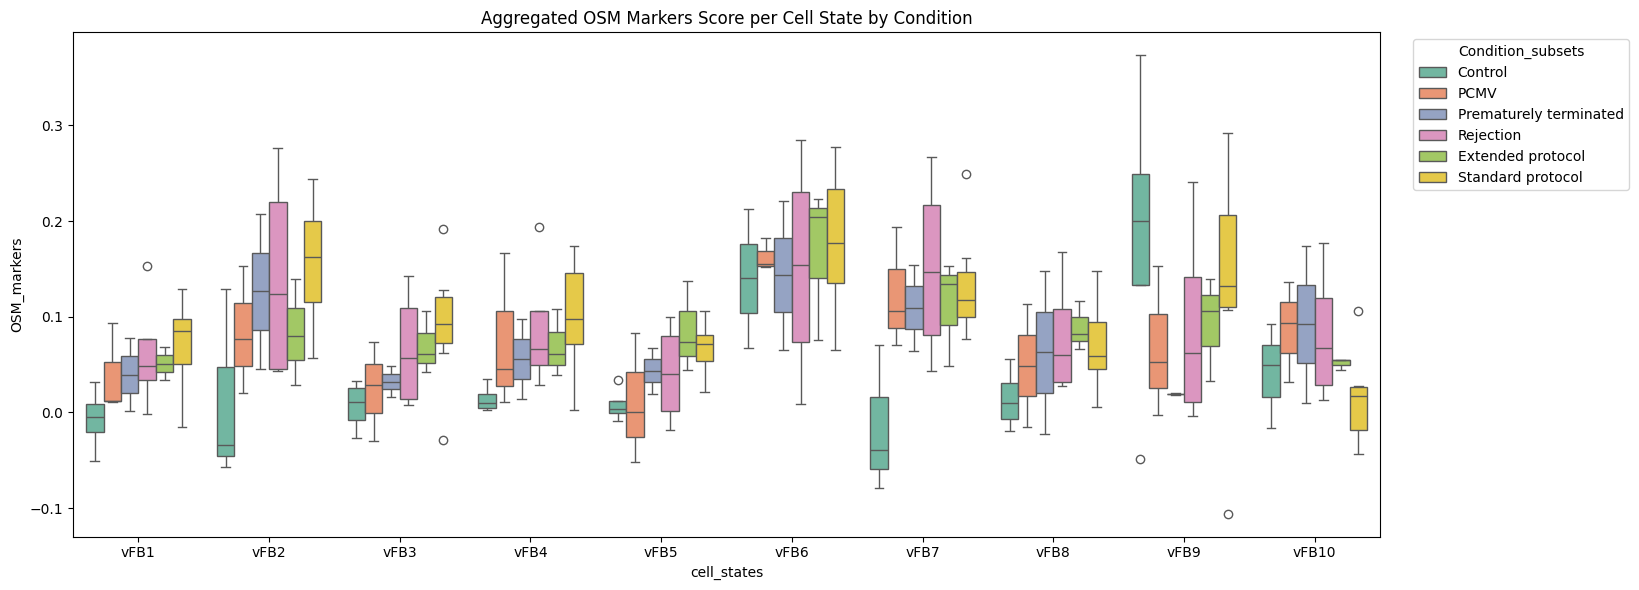

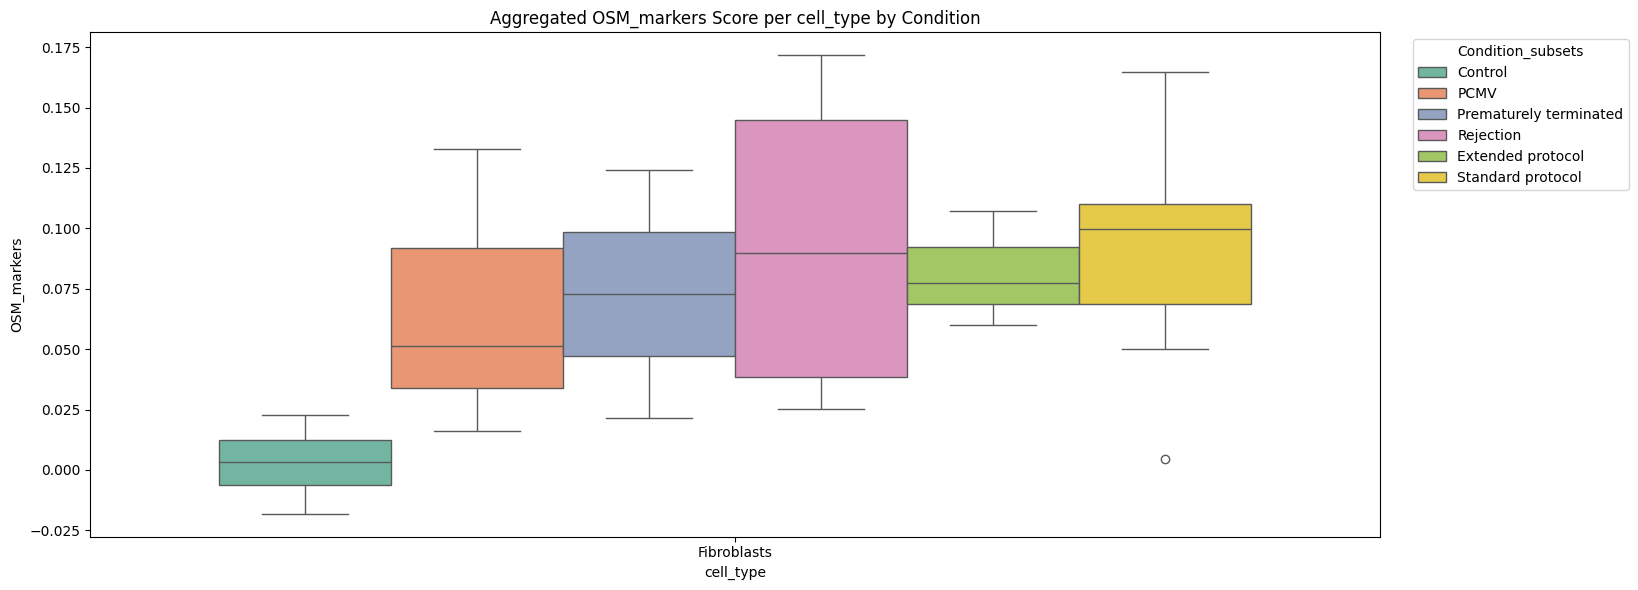

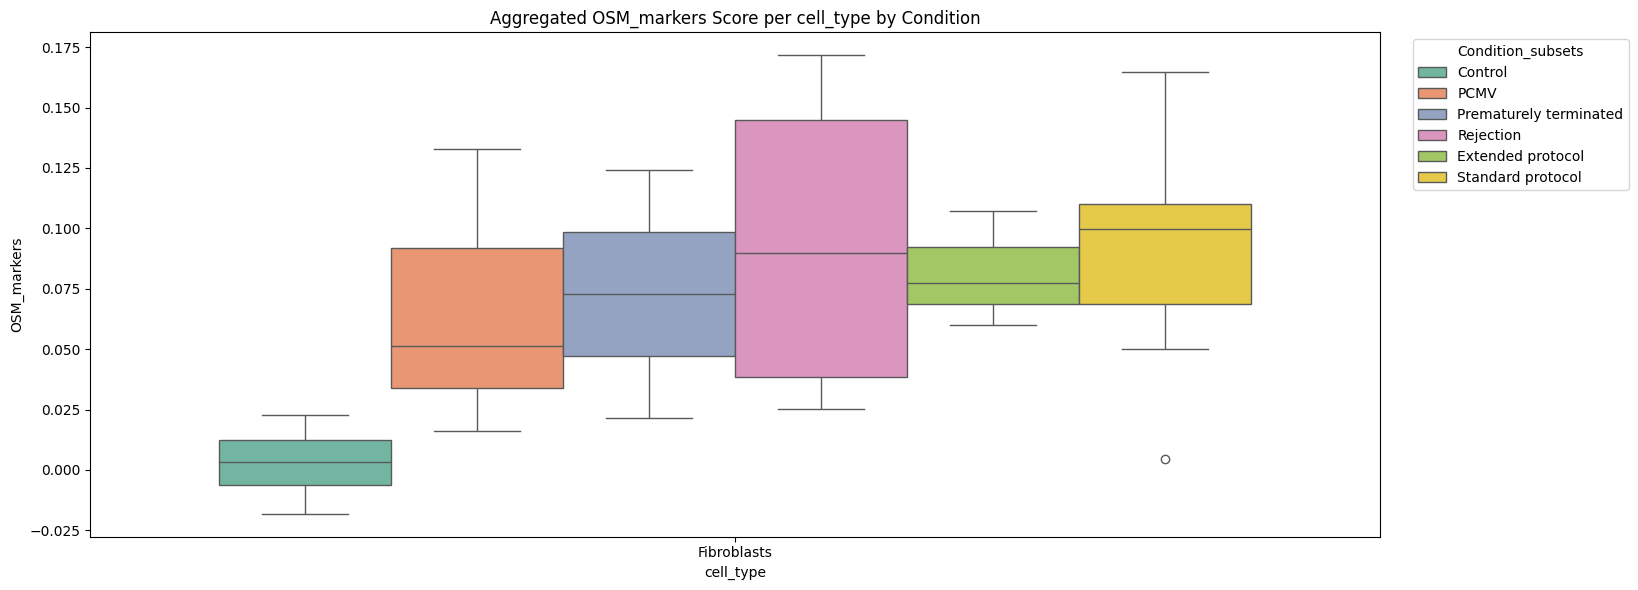

In [100]:
OSM_markers = [
    'Sus_scrofa___IL6ST', 'Sus_scrofa___OSMR', 'Sus_scrofa___PTPN11',
    'Sus_scrofa___VEGFA', 'Sus_scrofa___HIF1A',  'Sus_scrofa___FOS' ,  'Sus_scrofa___JUNB' , 
    'Sus_scrofa___CCL2',  'Sus_scrofa___RELA'
]

sc.pl.dotplot(
    global_FB_adata, 
    var_names=OSM_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=OSM_markers, score_name='OSM_markers')


scores_df = global_FB_adata.obs[['OSM_markers', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['OSM_markers'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated OSM_markers per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    palette='Set2'
)
plt.title('Aggregated OSM_markers per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------------------------------------------------------------------
# Aggregate per Sample and cell_state
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['OSM_markers'].median().reset_index()

# Extract unique mapping of Sample_ID to Condition_subsets (only once!)
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()

# Merge once
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Now plot with the correct column
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    hue='Condition_subsets',   # <--- use this!
    palette='Set2'
)
plt.title('Aggregated OSM Markers Score per Cell State by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


# -------------------------------------------------------------------------------------------------------------------------------------

# Add 'cell_type' to scores_df if present in obs
if 'cell_type' in global_FB_adata.obs.columns:
    scores_df = global_FB_adata.obs[['OSM_markers', 'Sample_ID', 'cell_type']].copy()
else:
    print('cell_type not in obs columns:', global_FB_adata.obs.columns)
    # You might want to use a different column or check for typos


# Now group and aggregate as planned
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['OSM_markers'].median().reset_index()

# Merge with condition_map
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='OSM_markers',
    hue='Condition_subsets',
    palette='Set2'
)
plt.title('Aggregated OSM_markers Score per cell_type by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



# ---------------------------------------------------------------------------------------------------------------


# Add 'cell_type' to scores_df if present in obs
if 'cell_type' in global_FB_adata.obs.columns:
    scores_df = global_FB_adata.obs[['OSM_markers', 'Sample_ID', 'cell_type']].copy()
else:
    print('cell_type not in obs columns:', global_FB_adata.obs.columns)
    # You might want to use a different column or check for typos


# Now group and aggregate as planned
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['OSM_markers'].median().reset_index()

# Merge with condition_map
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='OSM_markers',
    hue='Condition_subsets',
    palette='Set2'
)
plt.title('Aggregated OSM_markers Score per cell_type by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


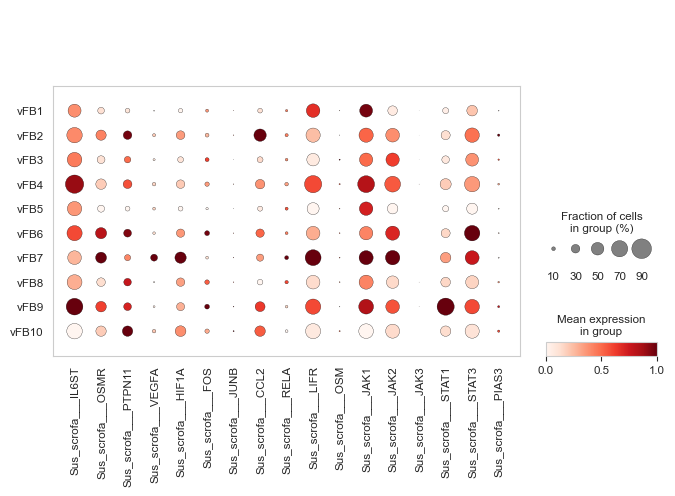

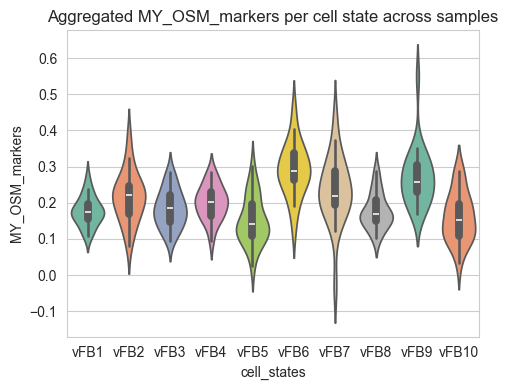

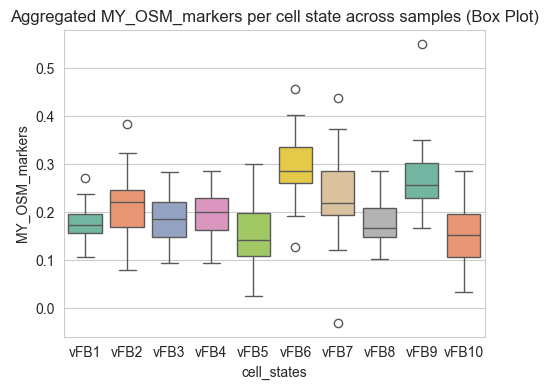

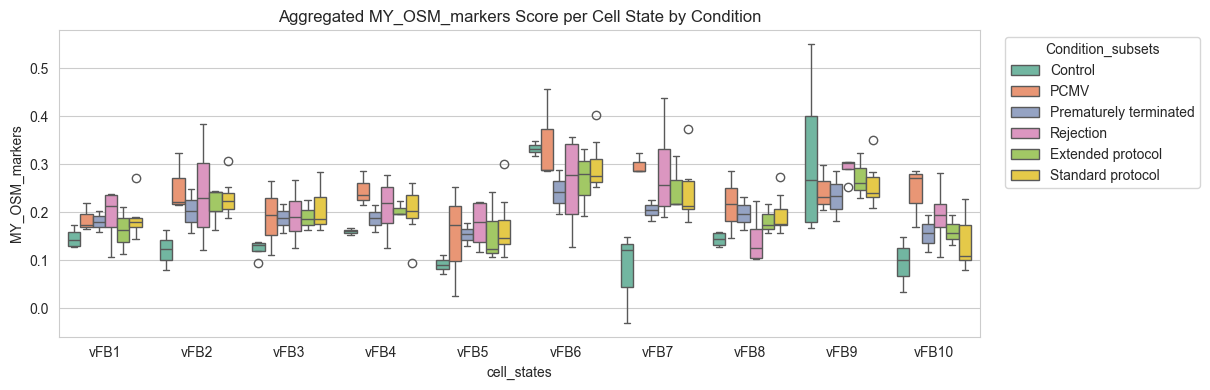

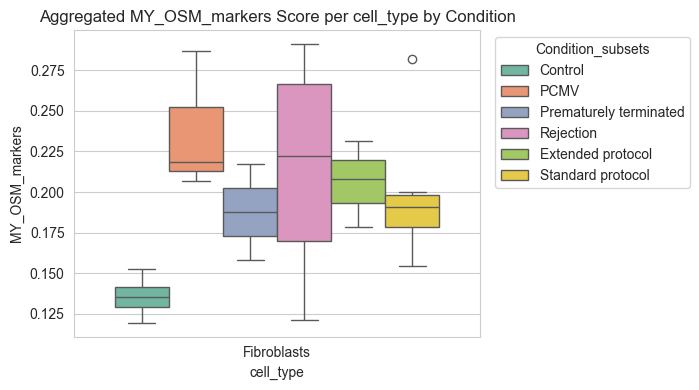

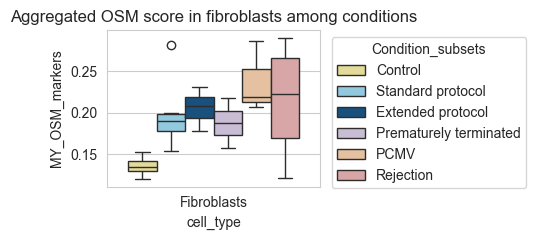

In [196]:
MY_OSM_markers = [
    'Sus_scrofa___IL6ST', 'Sus_scrofa___OSMR','Sus_scrofa___PTPN11',
    'Sus_scrofa___VEGFA', 'Sus_scrofa___HIF1A',  'Sus_scrofa___FOS' ,  'Sus_scrofa___JUNB' , 
    'Sus_scrofa___CCL2',  'Sus_scrofa___RELA',

    'Sus_scrofa___LIFR', 'Sus_scrofa___OSM', 'Sus_scrofa___JAK1', 'Sus_scrofa___JAK2', 'Sus_scrofa___JAK3', 
    'Sus_scrofa___STAT1', 'Sus_scrofa___STAT3', 'Sus_scrofa___PIAS3', 

]

sc.pl.dotplot(
    global_FB_adata, 
    var_names=MY_OSM_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=MY_OSM_markers, score_name='MY_OSM_markers')


scores_df = global_FB_adata.obs[['MY_OSM_markers', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['MY_OSM_markers'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(5, 4))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='MY_OSM_markers',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated MY_OSM_markers per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='MY_OSM_markers',
    palette='Set2'
)
plt.title('Aggregated MY_OSM_markers per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------------------------------------------------------------------
# Aggregate per Sample and cell_state
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['MY_OSM_markers'].median().reset_index()

# Extract unique mapping of Sample_ID to Condition_subsets (only once!)
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()

# Merge once
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Now plot with the correct column
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='MY_OSM_markers',
    hue='Condition_subsets',   # <--- use this!
    palette='Set2'
)
plt.title('Aggregated MY_OSM_markers Score per Cell State by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


# -------------------------------------------------------------------------------------------------------------------------------------

# Add 'cell_type' to scores_df if present in obs
if 'cell_type' in global_FB_adata.obs.columns:
    scores_df = global_FB_adata.obs[['MY_OSM_markers', 'Sample_ID', 'cell_type']].copy()
else:
    print('cell_type not in obs columns:', global_FB_adata.obs.columns)
    # You might want to use a different column or check for typos


# Now group and aggregate as planned
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['MY_OSM_markers'].median().reset_index()

# Merge with condition_map
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Plot
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette='Set2'
)
plt.title('Aggregated MY_OSM_markers Score per cell_type by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



# ---------------------------------------------------------------------------------------------------------------


# Mapping condition to color (as you provided)
custom_palette = {
    'Control':      '#EFE48E',
    'Standard protocol': 'skyblue',
    'Extended protocol': '#08528f',
    'Prematurely terminated': '#C9B8D9',
    'PCMV':         '#F0C096',
    'Rejection':    '#E09E9E'
}

# Set the desired order for display in the plot and legend
hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    'Prematurely terminated',
    'PCMV',
    'Rejection'
]

plt.figure(figsize=(3, 2.5))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=custom_palette,
    hue_order=hue_order
)
plt.title('Aggregated OSM score in fibroblasts among conditions')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# ---------------------------------------------------------------------------------------------------------------


# # Now group and aggregate as planned
# agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['MY_OSM_markers'].median().reset_index()

# # Merge with condition_map
# condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
# agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# # Plot
# plt.figure(figsize=(14, 6))
# sns.boxplot(
#     data=agg_scores,
#     x='cell_type',
#     y='MY_OSM_markers',
#     hue='Condition_subsets',
#     palette='Set2'
# )
# plt.title('Aggregated MY_OSM_markers Score per cell_type by Condition')
# plt.tight_layout()
# plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.show()



# ---------------------------------------------------------------------------------------------------------------



<Figure size 400x600 with 0 Axes>

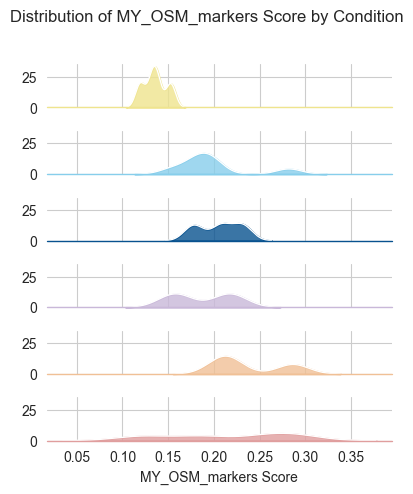

In [195]:
# Define your custom colors and order
custom_palette = {
    'Control':      '#EFE48E',
    'Standard protocol': 'skyblue',
    'Extended protocol': '#08528f',
    'Prematurely terminated': '#C9B8D9',
    'PCMV':         '#F0C096',
    'Rejection':    '#E09E9E'
}

hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    'Prematurely terminated',
    'PCMV',
    'Rejection'
]

# Prepare data (already done, but included for completeness)
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['MY_OSM_markers'].median().reset_index()
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Make a smaller ridgeline plot with your palette/order
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 6))  # Make the plot smaller

g = sns.FacetGrid(
    agg_scores, 
    row='Condition_subsets', 
    hue='Condition_subsets',
    row_order=hue_order,
    hue_order=hue_order,
    aspect=5,  # less wide, more vertical
    height=0.8,  # smaller height per facet
    palette=custom_palette
)
g.map(
    sns.kdeplot, 
    'MY_OSM_markers', 
    bw_adjust=0.5, 
    clip_on=False, 
    fill=True, 
    alpha=0.8, 
    linewidth=1.2
)
g.map(
    sns.kdeplot, 
    'MY_OSM_markers', 
    clip_on=False, 
    color="w", 
    lw=1, 
    bw_adjust=0.5
)
g.map(plt.axhline, y=0, lw=1, clip_on=False)

g.fig.subplots_adjust(left=0.25)  # To avoid y-label cut-off
g.fig.suptitle('Distribution of MY_OSM_markers Score by Condition', y=1.02, fontsize=12)
g.set_axis_labels("MY_OSM_markers Score", "")
g.set_titles("")
g.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()


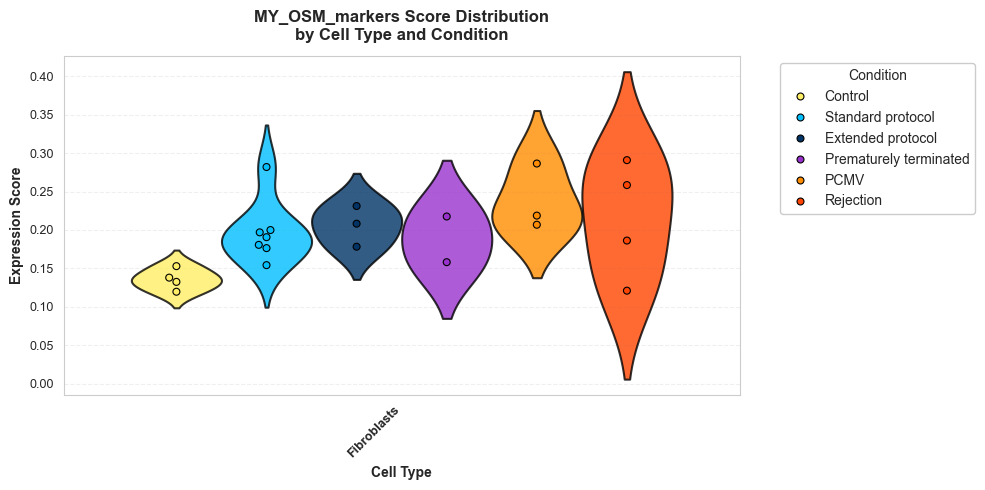

In [162]:
plt.figure(figsize=(10, 5))  # Compact but readable size

# Custom vibrant palette (no fading)
custom_palette = {
    'Control': '#FFEE66',        # Bright yellow
    'Standard protocol': '#00BFFF',  # Deep sky blue
    'Extended protocol': '#003366',  # Rich navy
    'Prematurely terminated': '#9932CC',  # Vibrant purple
    'PCMV': '#FF8C00',          # Dark orange
    'Rejection': '#FF4500'      # Intense red
}

hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    'Prematurely terminated',
    'PCMV',
    'Rejection'
]

# Create violin plot with solid colors
sns.violinplot(data=agg_scores, x='cell_type', y='MY_OSM_markers', 
              hue='Condition_subsets', palette=custom_palette,
              hue_order=hue_order, inner=None, alpha=0.8,  # Increased opacity
              saturation=1,  # Full saturation
              linewidth=1.5, edgecolor='black')

# Create swarm plot with matching vibrant colors
sns.swarmplot(data=agg_scores, x='cell_type', y='MY_OSM_markers', 
             hue='Condition_subsets', palette=custom_palette,
             hue_order=hue_order, dodge=True, size=5,
             edgecolor='black', linewidth=0.8)

# Enhanced styling
plt.title('MY_OSM_markers Score Distribution\nby Cell Type and Condition', 
         fontsize=12, pad=12, fontweight='bold')
plt.ylabel('Expression Score', fontsize=10, fontweight='bold')
plt.xlabel('Cell Type', fontsize=10, fontweight='bold')

# Improved legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicates
plt.legend(by_label.values(), by_label.keys(), 
           title='Condition', title_fontsize=10,
           bbox_to_anchor=(1.05, 1), loc='upper left',
           frameon=True, framealpha=1)

# Adjust ticks
plt.xticks(rotation=45, ha='right', fontsize=9, fontweight='bold')
plt.yticks(fontsize=9)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

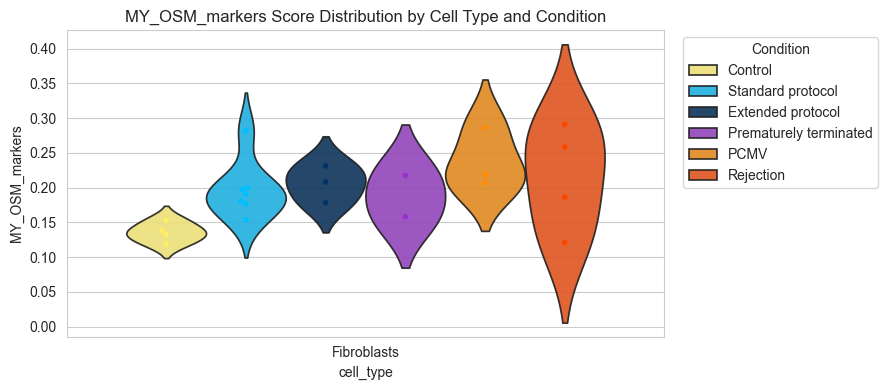

In [169]:
plt.figure(figsize=(9, 4))  # smaller figure

# Violin plot (no alpha, uses your custom palette)
sns.violinplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=custom_palette,
    hue_order=hue_order,
    inner=None,
         alpha=0.9    
)

# Swarm plot (use same palette and order, dodge=True for splitting by condition)
sns.swarmplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=custom_palette,
    hue_order=hue_order,
    dodge=True,
    size=4, 
    edgecolor='gray'
)

plt.title('MY_OSM_markers Score Distribution by Cell Type and Condition', fontsize=12)

# To avoid duplicate legends (since both plots add one), remove one of them:
handles, labels = plt.gca().get_legend_handles_labels()
n_per_cond = len(hue_order)
plt.legend(
    handles[:n_per_cond], labels[:n_per_cond],  # only show one set
    title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left'
)

plt.tight_layout()
plt.show()


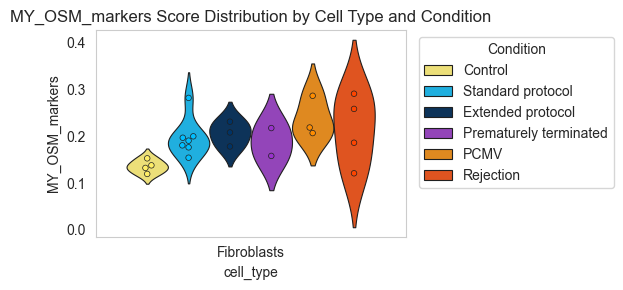

In [179]:
from matplotlib.colors import to_rgba

# Construct a faded (alpha) version of your custom palette
faded_palette = {k: to_rgba(v, alpha=0.6) for k, v in custom_palette.items()}

plt.figure(figsize=(6, 3))

# Violin plot with alpha (using faded palette)
sns.violinplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=faded_palette,
    hue_order=hue_order,
    inner=None,
    linewidth=0.8
)

# Swarm plot overlays (using full color palette, more visible dots)
sns.swarmplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=custom_palette,  # original (non-faded) for better point visibility
    hue_order=hue_order,
    dodge=True,
    size=4, 
    edgecolor='gray',
    linewidth=0.5
)

plt.title('MY_OSM_markers Score Distribution by Cell Type and Condition', fontsize=12)

# Remove grid (Seaborn sometimes adds it by default)
plt.grid(False)

# Remove duplicate legends (keep only one legend for conditions)
handles, labels = plt.gca().get_legend_handles_labels()
n_per_cond = len(hue_order)
plt.legend(
    handles[:n_per_cond], labels[:n_per_cond],
    title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left'
)

plt.tight_layout()
plt.show()


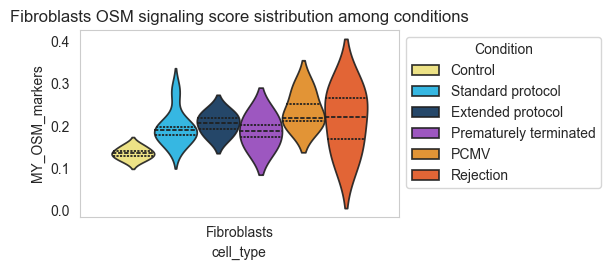

In [194]:
plt.figure(figsize=(6, 2.8))
sns.violinplot(
    data=agg_scores,
    x='cell_type',
    y='MY_OSM_markers',
    hue='Condition_subsets',
    palette=custom_palette,
    hue_order=hue_order,
    inner='quartile' , # adds quartile lines for reference
     alpha=0.9    
)
plt.title('Fibroblasts OSM signaling score sistribution among conditions', fontsize=12)
plt.legend(title='Condition', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.show()


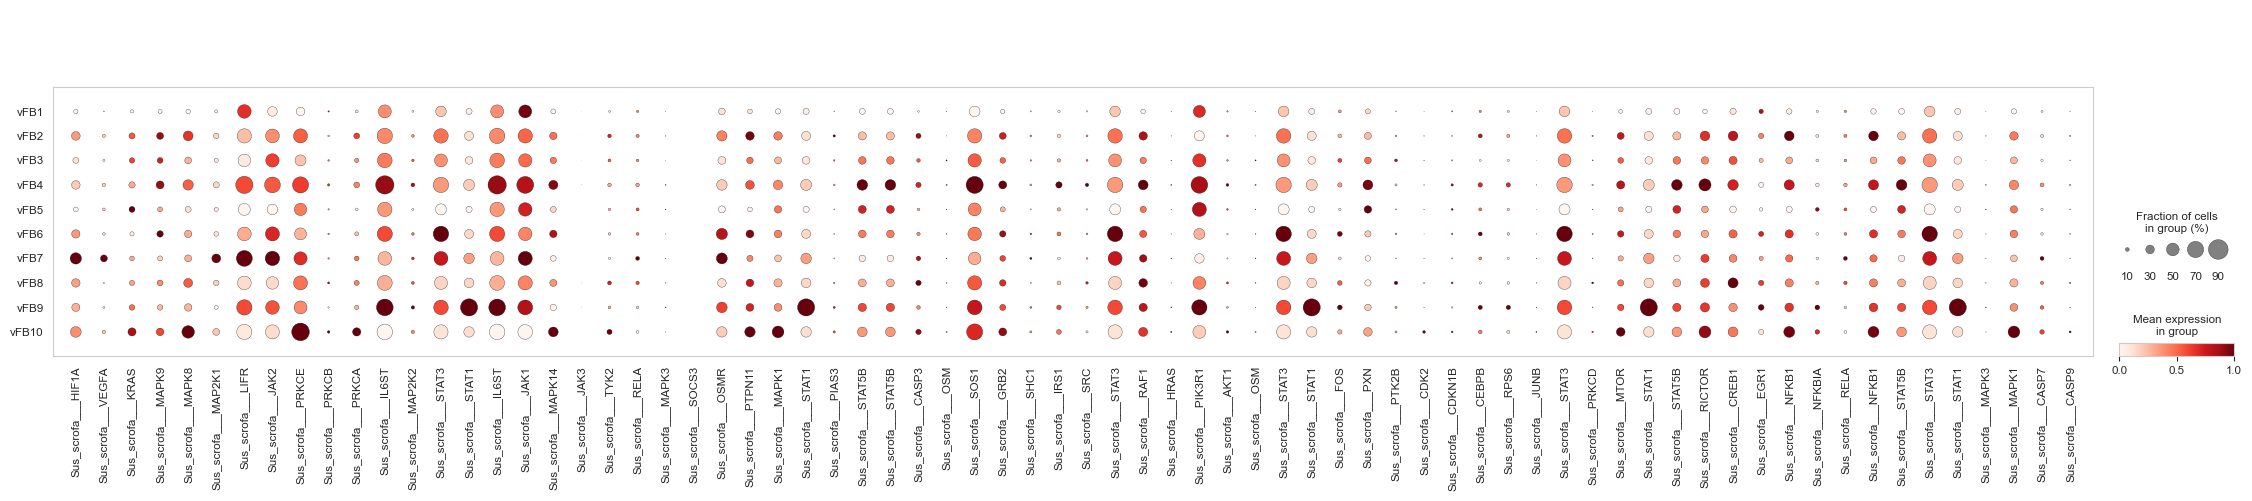

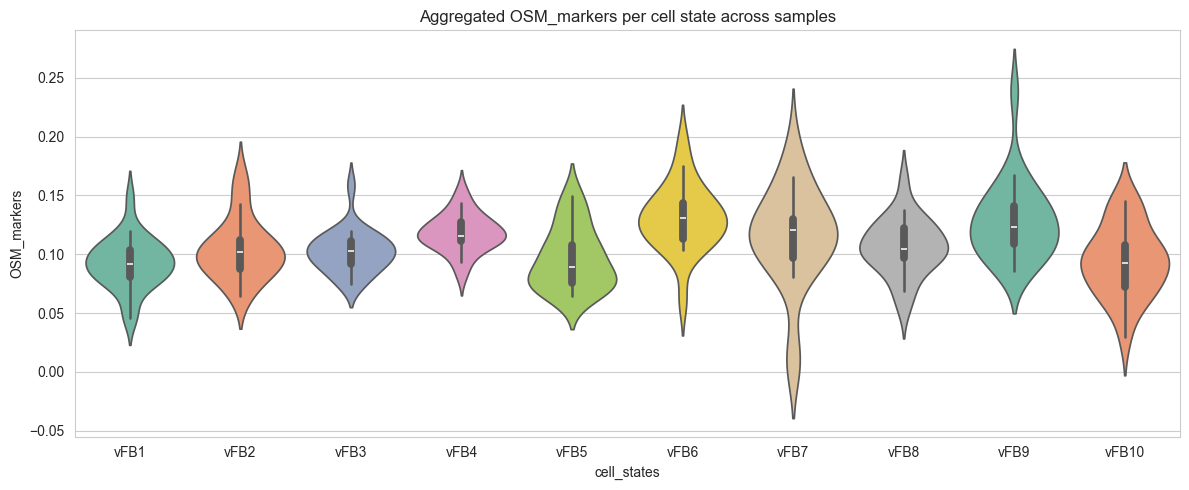

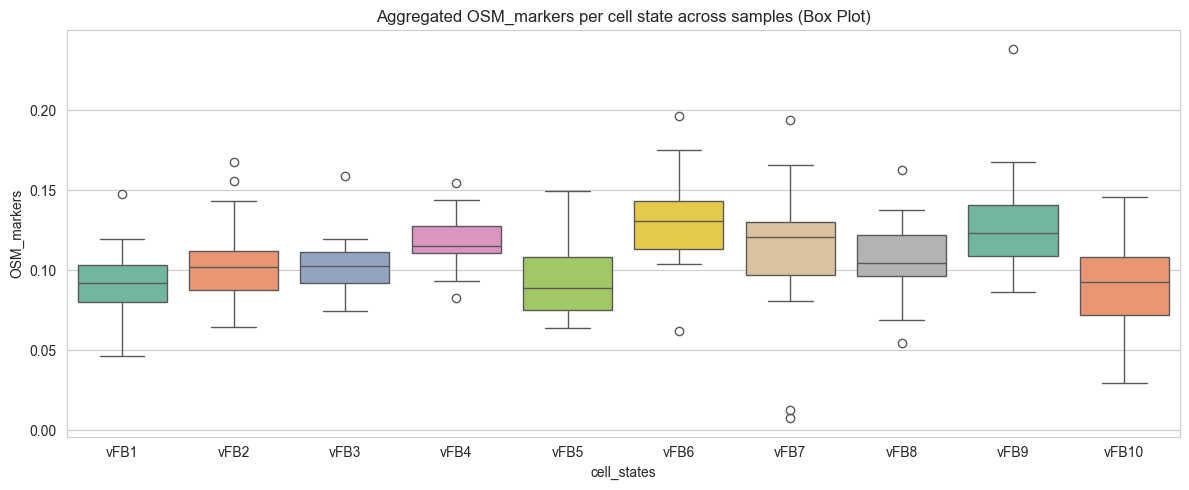

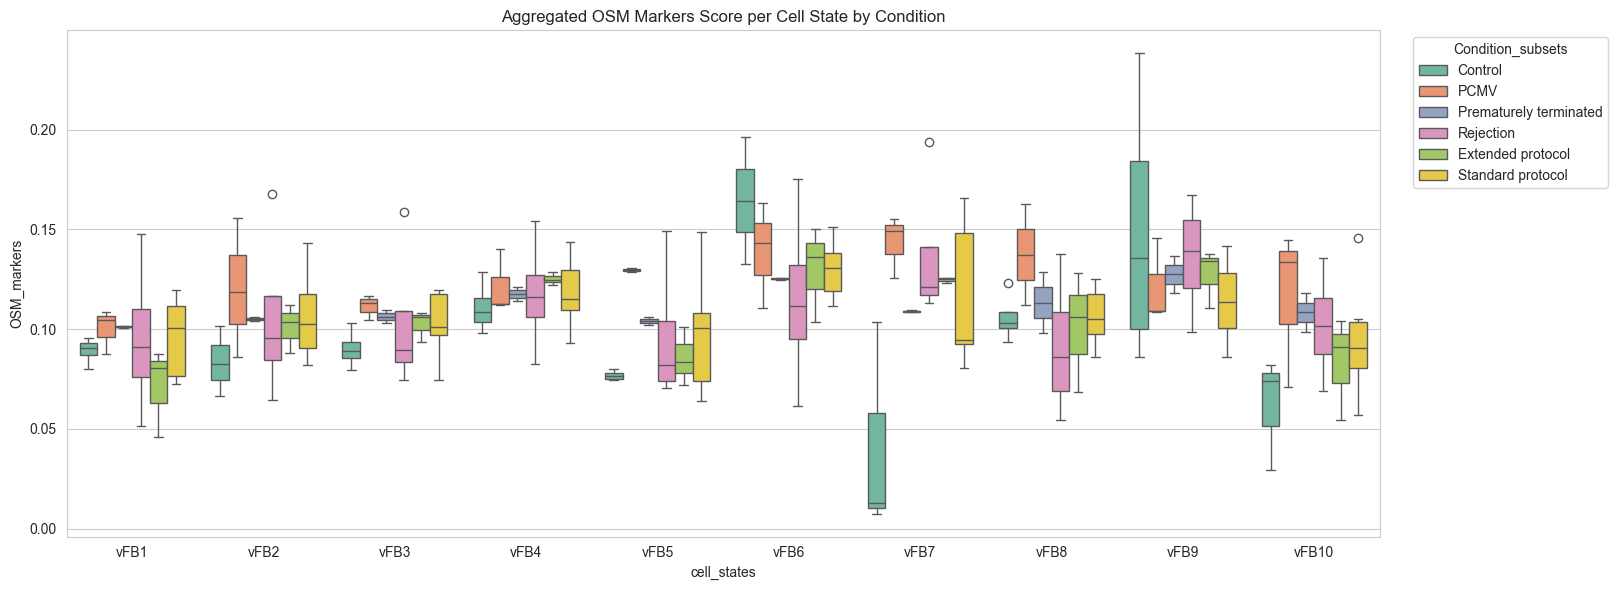

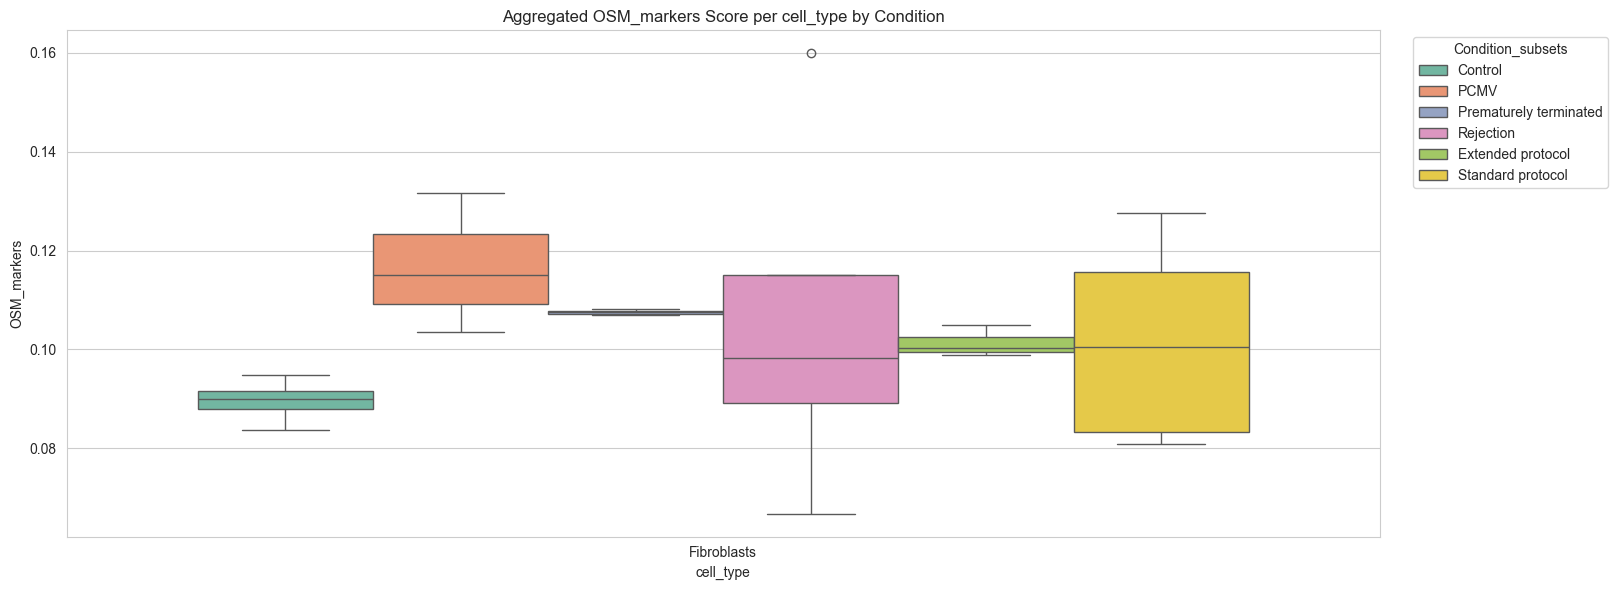

In [202]:
Felix_OSM_markers = [
'Sus_scrofa___HIF1A', 'Sus_scrofa___VEGFA', 'Sus_scrofa___KRAS', 'Sus_scrofa___MAPK9', 
'Sus_scrofa___MAPK8', 'Sus_scrofa___MAP2K1', 'Sus_scrofa___LIFR', 'Sus_scrofa___JAK2',
'Sus_scrofa___PRKCE', 'Sus_scrofa___PRKCB', 'Sus_scrofa___PRKCA', 'Sus_scrofa___IL6ST', 'Sus_scrofa___MAP2K2', 
'Sus_scrofa___STAT3', 'Sus_scrofa___STAT1', 'Sus_scrofa___IL6ST', 'Sus_scrofa___JAK1', 'Sus_scrofa___MAPK14', 
'Sus_scrofa___JAK3', 'Sus_scrofa___TYK2', 'Sus_scrofa___RELA', 'Sus_scrofa___MAPK3', 'Sus_scrofa___SOCS3', 
'Sus_scrofa___OSMR', 'Sus_scrofa___PTPN11', 'Sus_scrofa___MAPK1', 'Sus_scrofa___STAT1', 'Sus_scrofa___PIAS3', 
'Sus_scrofa___STAT5B', 'Sus_scrofa___STAT5B', 'Sus_scrofa___CASP3', 'Sus_scrofa___OSM', 'Sus_scrofa___SOS1', 
'Sus_scrofa___GRB2', 'Sus_scrofa___SHC1', 'Sus_scrofa___IRS1', 'Sus_scrofa___SRC', 'Sus_scrofa___STAT3', 
'Sus_scrofa___RAF1', 'Sus_scrofa___HRAS', 'Sus_scrofa___PIK3R1', 'Sus_scrofa___AKT1', 'Sus_scrofa___OSM', 
'Sus_scrofa___STAT3', 'Sus_scrofa___STAT1', 'Sus_scrofa___FOS', 'Sus_scrofa___PXN', 'Sus_scrofa___PTK2B', 
'Sus_scrofa___CDK2', 'Sus_scrofa___CDKN1B', 'Sus_scrofa___CEBPB', 'Sus_scrofa___RPS6', 'Sus_scrofa___JUNB', 
'Sus_scrofa___STAT3', 'Sus_scrofa___PRKCD', 'Sus_scrofa___MTOR', 'Sus_scrofa___STAT1', 'Sus_scrofa___STAT5B', 
'Sus_scrofa___RICTOR', 'Sus_scrofa___CREB1', 'Sus_scrofa___EGR1', 'Sus_scrofa___NFKB1', 'Sus_scrofa___NFKBIA', 
'Sus_scrofa___RELA', 'Sus_scrofa___NFKB1', 'Sus_scrofa___STAT5B', 'Sus_scrofa___STAT3', 'Sus_scrofa___STAT1', 
'Sus_scrofa___MAPK3', 'Sus_scrofa___MAPK1', 'Sus_scrofa___CASP7', 'Sus_scrofa___CASP9'
]


sc.pl.dotplot(
    global_FB_adata, 
    var_names=Felix_OSM_markers, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=Felix_OSM_markers, score_name='OSM_markers')


scores_df = global_FB_adata.obs[['OSM_markers', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['OSM_markers'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated OSM_markers per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    palette='Set2'
)
plt.title('Aggregated OSM_markers per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()



# ----------------------------------------------------------------------------

# Aggregate per Sample and cell_state
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['OSM_markers'].median().reset_index()

# Extract unique mapping of Sample_ID to Condition_subsets (only once!)
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()

# Merge once
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Now plot with the correct column
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='OSM_markers',
    hue='Condition_subsets',   # <--- use this!
    palette='Set2'
)
plt.title('Aggregated OSM Markers Score per Cell State by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



# ----------------------------------------------------------------------------

# Add 'cell_type' to scores_df if present in obs
if 'cell_type' in global_FB_adata.obs.columns:
    scores_df = global_FB_adata.obs[['OSM_markers', 'Sample_ID', 'cell_type']].copy()
else:
    print('cell_type not in obs columns:', global_FB_adata.obs.columns)
    # You might want to use a different column or check for typos


# Now group and aggregate as planned
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['OSM_markers'].median().reset_index()

# Merge with condition_map
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='OSM_markers',
    hue='Condition_subsets',
    palette='Set2'
)
plt.title('Aggregated OSM_markers Score per cell_type by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()


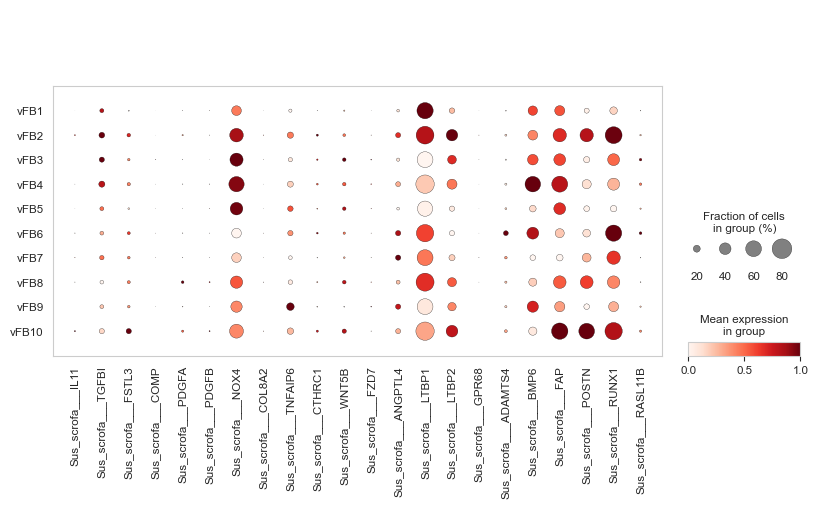

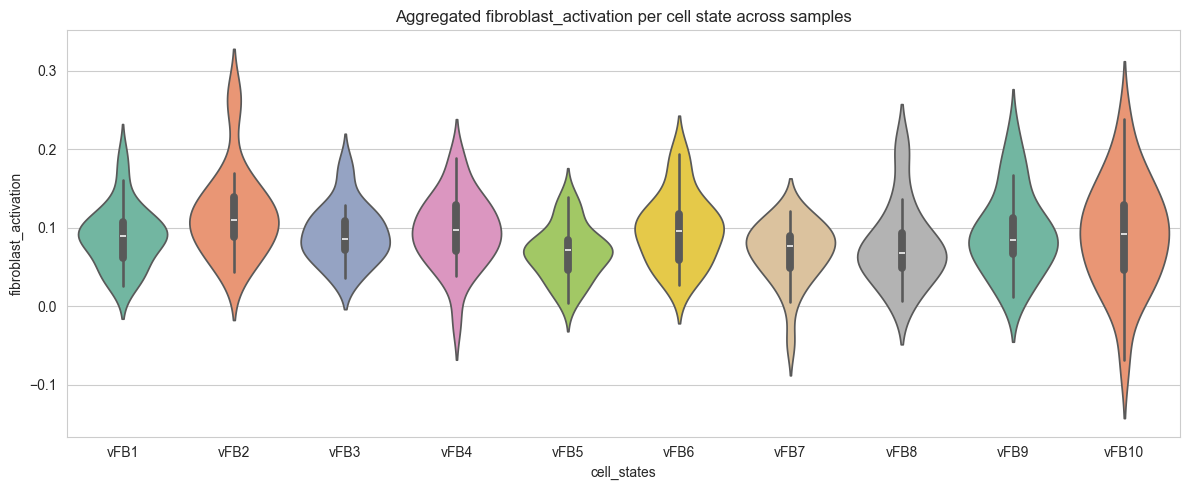

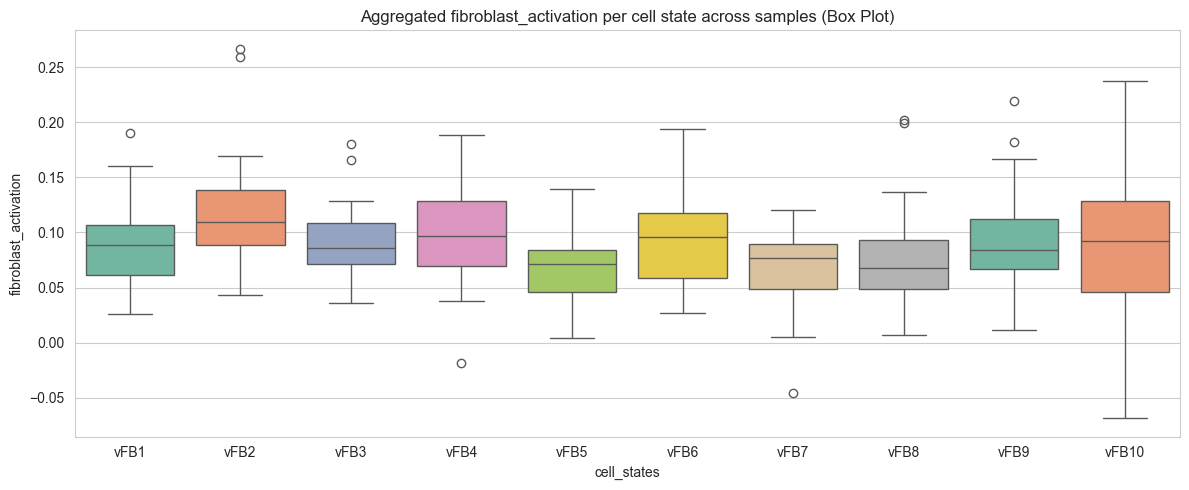

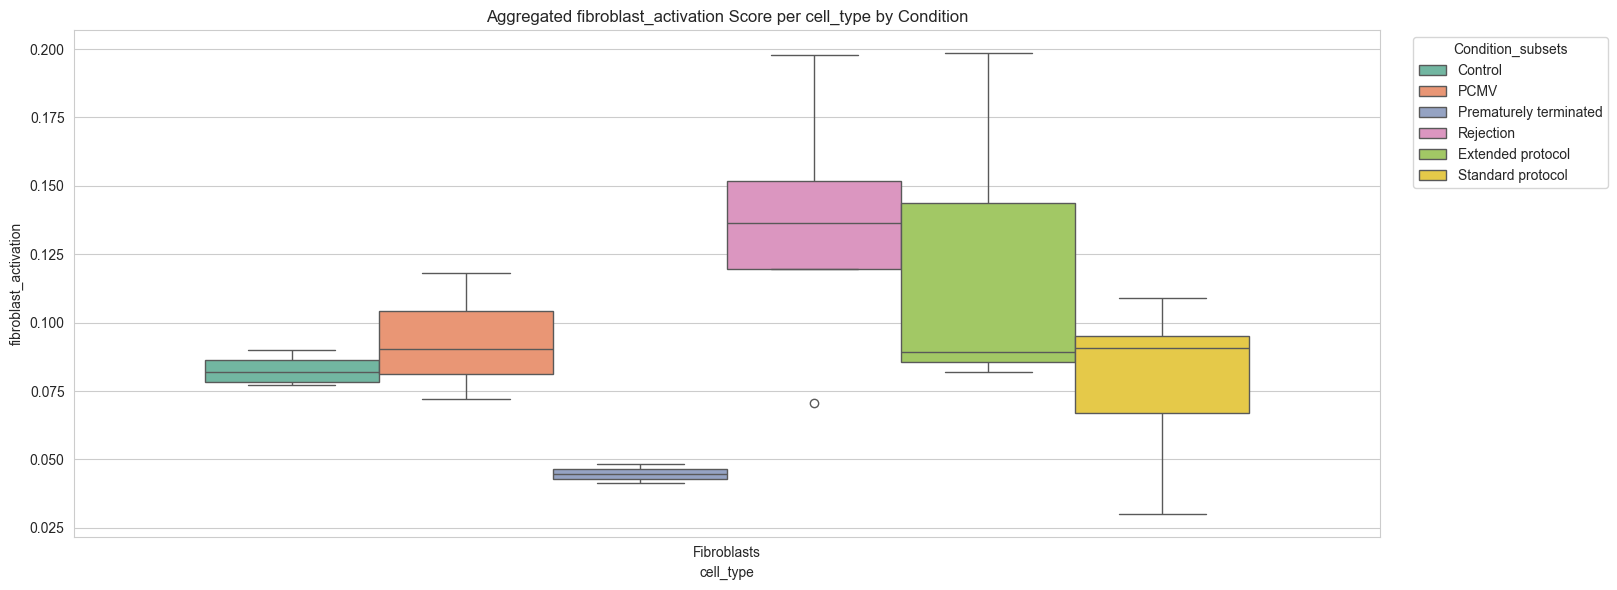

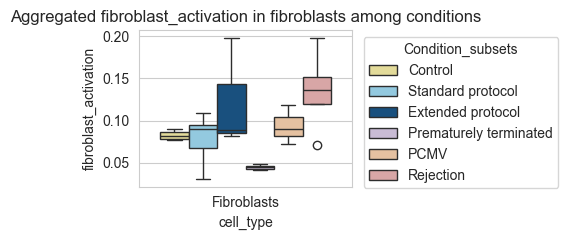

In [210]:
fibroblast_activation = [
    'Sus_scrofa___IL11', 'Sus_scrofa___TGFBI', 'Sus_scrofa___FSTL3', 'Sus_scrofa___COMP',
    'Sus_scrofa___PDGFA', 'Sus_scrofa___PDGFB', 'Sus_scrofa___NOX4', 'Sus_scrofa___COL8A2',
    'Sus_scrofa___TNFAIP6', 'Sus_scrofa___CTHRC1', 'Sus_scrofa___WNT5B', 'Sus_scrofa___FZD7',
    'Sus_scrofa___ANGPTL4', 'Sus_scrofa___LTBP1', 'Sus_scrofa___LTBP2', 'Sus_scrofa___GPR68',
    'Sus_scrofa___ADAMTS4', 'Sus_scrofa___BMP6', 'Sus_scrofa___FAP',

     'Sus_scrofa___POSTN',
    'Sus_scrofa___RUNX1', 'Sus_scrofa___RASL11B'
]



sc.pl.dotplot(
    global_FB_adata, 
    var_names=fibroblast_activation, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

sc.tl.score_genes(global_FB_adata, gene_list=fibroblast_activation, score_name='fibroblast_activation')


scores_df = global_FB_adata.obs[['fibroblast_activation', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['fibroblast_activation'].median().reset_index()


# ----------- Violin plot ------------------
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=agg_scores,
    x='cell_states',
    y='fibroblast_activation',
    palette='Set2'  # Or try 'tab10', 'tab20', etc. for more colors
)
plt.title('Aggregated fibroblast_activation per cell state across samples')
plt.tight_layout()
plt.show()


# ----------- Box plot ------------------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='fibroblast_activation',
    palette='Set2'
)
plt.title('Aggregated fibroblast_activation per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()



# ----------------------------------------------------------------------------

# Aggregate per Sample and cell_state
# agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['fibroblast_activation'].median().reset_index()

# # Extract unique mapping of Sample_ID to Condition_subsets (only once!)
# condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()

# # Merge once
# agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# # Now plot with the correct column
# plt.figure(figsize=(14, 6))
# sns.boxplot(
#     data=agg_scores,
#     x='fibroblast_activation',
#     y='fibroblast_activation',
#     hue='Condition_subsets',   # <--- use this!
#     palette='Set2'
# )
# plt.title('Aggregated fibroblast_activation Score per Cell State by Condition')
# plt.tight_layout()
# plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.show()



# ----------------------------------------------------------------------------

# Add 'cell_type' to scores_df if present in obs
if 'cell_type' in global_FB_adata.obs.columns:
    scores_df = global_FB_adata.obs[['fibroblast_activation', 'Sample_ID', 'cell_type']].copy()
else:
    print('cell_type not in obs columns:', global_FB_adata.obs.columns)
    # You might want to use a different column or check for typos


# Now group and aggregate as planned
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['fibroblast_activation'].median().reset_index()

# Merge with condition_map
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='fibroblast_activation',
    hue='Condition_subsets',
    palette='Set2'
)
plt.title('Aggregated fibroblast_activation Score per cell_type by Condition')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


# ---------------------------------------------------------------------------------------------------------
# Mapping condition to color (as you provided)
custom_palette = {
    'Control':      '#EFE48E',
    'Standard protocol': 'skyblue',
    'Extended protocol': '#08528f',
    'Prematurely terminated': '#C9B8D9',
    'PCMV':         '#F0C096',
    'Rejection':    '#E09E9E'
}

# Set the desired order for display in the plot and legend
hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    'Prematurely terminated',
    'PCMV',
    'Rejection'
]

plt.figure(figsize=(3, 2.5))
sns.boxplot(
    data=agg_scores,
    x='cell_type',
    y='fibroblast_activation',
    hue='Condition_subsets',
    palette=custom_palette,
    hue_order=hue_order
)
plt.title('Aggregated fibroblast_activation in fibroblasts among conditions')
plt.tight_layout()
plt.legend(title='Condition_subsets', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



<Figure size 400x600 with 0 Axes>

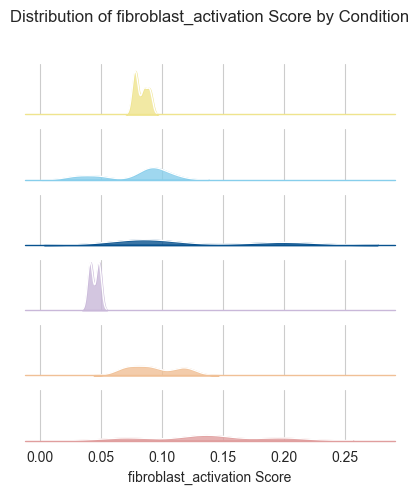

In [212]:
# Define your custom colors and order
custom_palette = {
    'Control':      '#EFE48E',
    'Standard protocol': 'skyblue',
    'Extended protocol': '#08528f',
    'Prematurely terminated': '#C9B8D9',
    'PCMV':         '#F0C096',
    'Rejection':    '#E09E9E'
}

hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    'Prematurely terminated',
    'PCMV',
    'Rejection'
]

# Prepare data (already done, but included for completeness)
agg_scores = scores_df.groupby(['Sample_ID', 'cell_type'])['fibroblast_activation'].median().reset_index()
condition_map = global_FB_adata.obs[['Sample_ID', 'Condition_subsets']].drop_duplicates()
agg_scores = agg_scores.merge(condition_map, on='Sample_ID', how='left')

# Make a smaller ridgeline plot with your palette/order
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 6))  # Make the plot smaller

g = sns.FacetGrid(
    agg_scores, 
    row='Condition_subsets', 
    hue='Condition_subsets',
    row_order=hue_order,
    hue_order=hue_order,
    aspect=5,  # less wide, more vertical
    height=0.8,  # smaller height per facet
    palette=custom_palette
)
g.map(
    sns.kdeplot, 
    'fibroblast_activation', 
    bw_adjust=0.5, 
    clip_on=False, 
    fill=True, 
    alpha=0.8, 
    linewidth=1.2
)
g.map(
    sns.kdeplot, 
    'fibroblast_activation', 
    clip_on=False, 
    color="w", 
    lw=1, 
    bw_adjust=0.5
)
g.map(plt.axhline, y=0, lw=1, clip_on=False)

g.set(yticks=[], ylabel="")


g.fig.subplots_adjust(left=0.25)  # To avoid y-label cut-off
g.fig.suptitle('Distribution of fibroblast_activation Score by Condition', y=1.02, fontsize=12)
g.set_axis_labels("fibroblast_activation Score", "")
g.set_titles("")
g.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()


Index(['n_genes', 'scrublet_score_default', 'predicted_doublets_default',
       'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log',
       'predicted_doublets_log', 'percent_mito', 'percent_ribo',
       'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts',
       'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet',
       'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis',
       'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02',
       'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status',
       'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected',
       'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating',
       'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV',
       'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection',
       'Conditions', 'Condition_subsets'],
      dtype='object')


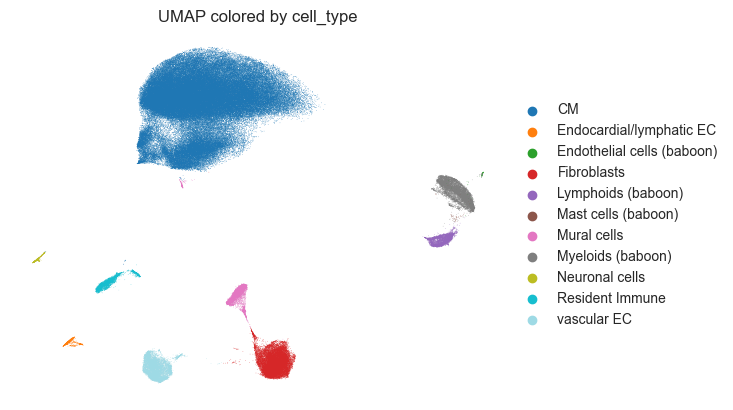

In [230]:

# Confirm the cell state column name (list all obs columns if unsure)
print(new_adata.obs.columns)

# Choose your groupby (update if needed)
groupby_col = 'cell_type'   # <- change if your column name is different!

# UMAP plot
sc.pl.umap(
    new_adata,
    color=groupby_col,
    # legend_loc='on data',   # 'right margin' or 'on data'
    title=f'UMAP colored by {groupby_col}',
    frameon=False,
    palette='tab20'         # or 'Set2', or your favorite palette
)


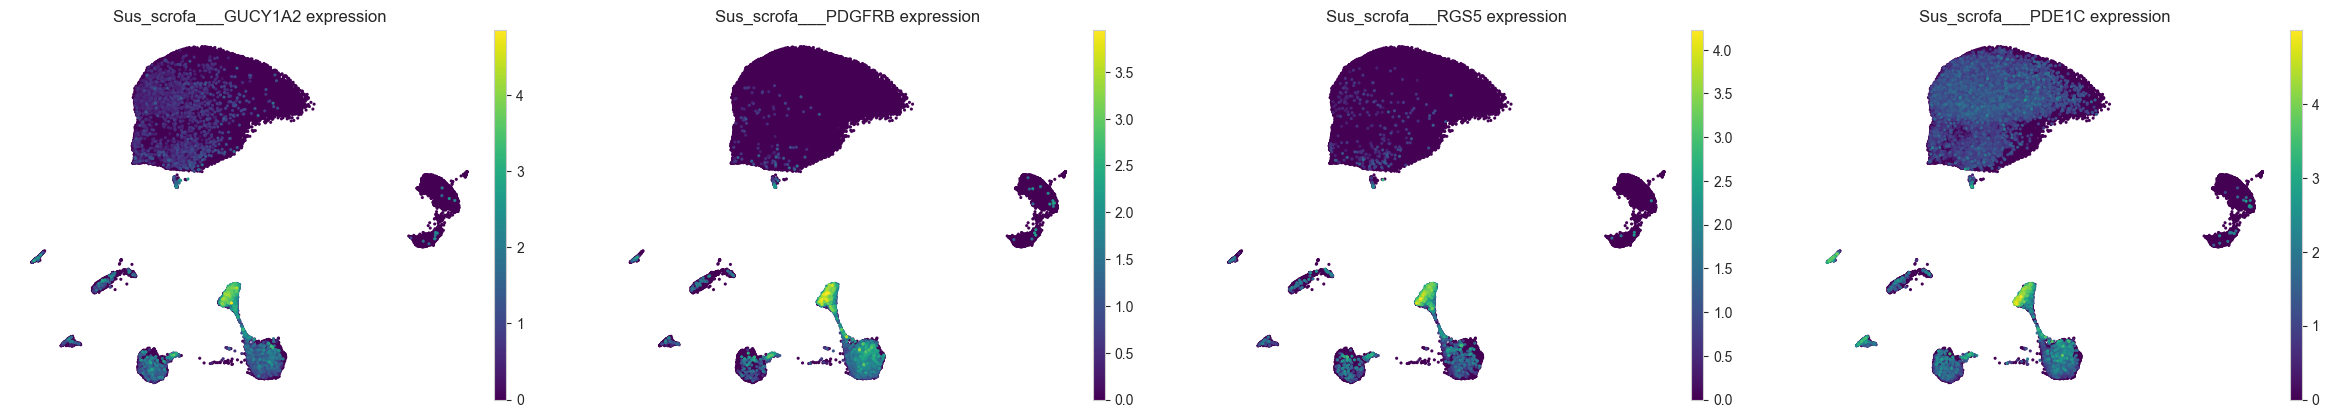

In [229]:
import scanpy as sc

# # Assuming new_adata is already loaded as above

# # Confirm the gene exists in your data (important with pig/human prefix naming!)
# print([gene for gene in new_adata.var_names if 'RGS5' in gene])

# # If you see e.g. 'Sus_scrofa___RGS5' in your var_names, use that exact name.
gene_name = [
    # 'Sus_scrofa___PRKG1',    # Most specific for pericytes
    'Sus_scrofa___GUCY1A2',  # Strong pericyte
    'Sus_scrofa___PDGFRB',   # Pericyte, but also SMC
    'Sus_scrofa___RGS5',     # Pericyte, also SMC

     'Sus_scrofa___PDE1C',

    
]

# Plot feature plot (gene expression on UMAP)
sc.pl.umap(
    new_adata,
    color=gene_name,
    cmap='viridis',         # or 'viridis', 'plasma', etc.
    frameon=False,
    size=20,                # Adjust point size if needed
     title=[f"{g} expression" for g in gene_name] 
)


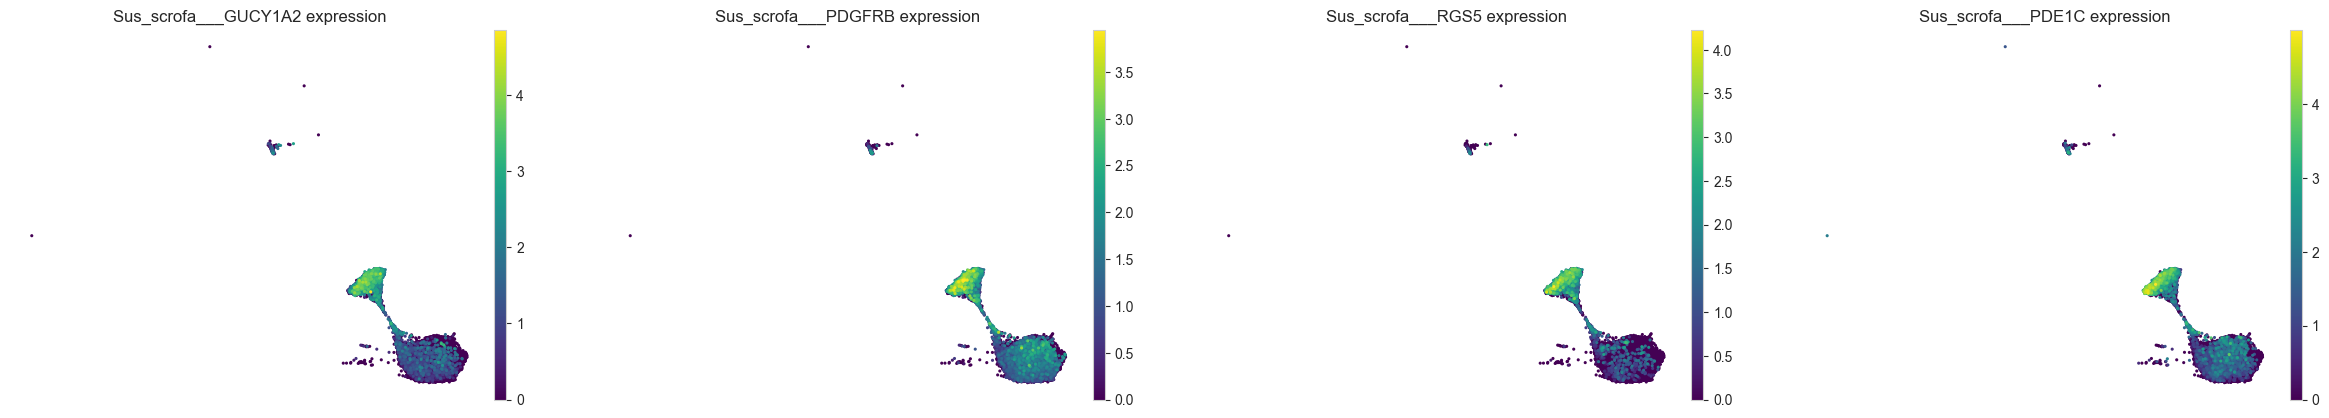

In [227]:
subset_adata = new_adata[new_adata.obs['cell_type'].isin(['Fibroblasts', 'Mural cells'])].copy()
sc.pl.umap(
    subset_adata,
    color=gene_name,       # list of genes, as before
    cmap='viridis',
    frameon=False,
    size=20,
    title=[f"{g} expression" for g in gene_name]  # makes one title per panel
)


# Final version of OSM based on subsetted global object

In [2]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [3]:
# Step 3: Normalize and log-transform
sc.pp.normalize_total(global_adata, target_sum=1e4)
sc.pp.log1p(global_adata)


In [4]:
# Create the masked AnnData object
FB_adata = global_adata[global_adata.obs['cell_type'] == 'Fibroblasts', :].copy()

print(f"Original AnnData shape: {global_adata.shape}")
print(f"Fibroblasts AnnData shape: {FB_adata.shape}")

Original AnnData shape: (186947, 40653)
Fibroblasts AnnData shape: (16322, 40653)


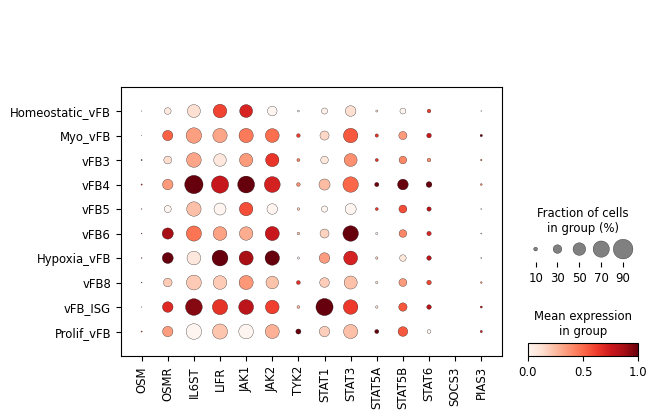

In [6]:
osm_core = [
'OSM', 'OSMR', 'IL6ST', 'LIFR', 'JAK1', 'JAK2', 'TYK2', 'STAT1', 'STAT3', 'STAT5A', 'STAT5B', 'STAT6', 'SOCS3', 'PIAS3'
]

sc.pl.dotplot(
    FB_adata, 
    var_names=osm_core, 
    groupby='cell_states',  # Replace with your column, e.g. 'leiden'
    standard_scale='var'
)

In [7]:
sc.tl.score_genes(FB_adata, gene_list=osm_core, score_name='osm_core')

scores_df = FB_adata.obs[['osm_core', 'Sample_ID', 'cell_states']].copy()
agg_scores = scores_df.groupby(['Sample_ID', 'cell_states'])['osm_core'].median().reset_index()


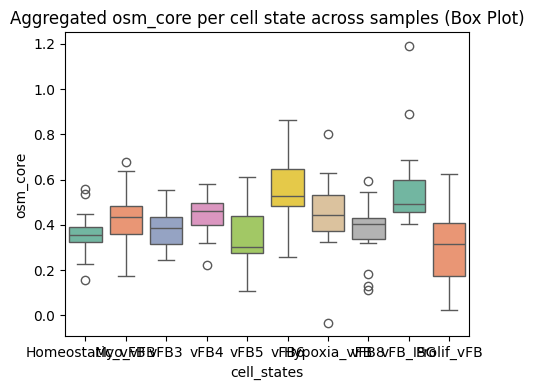

In [9]:
import seaborn as sns
# ----------- Box plot ------------------
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='osm_core',
    palette='Set2'
)
plt.title('Aggregated osm_core per cell state across samples (Box Plot)')
plt.tight_layout()
plt.show()



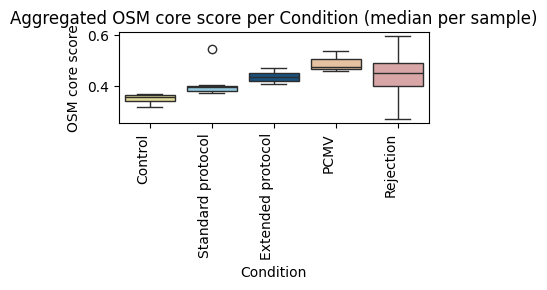

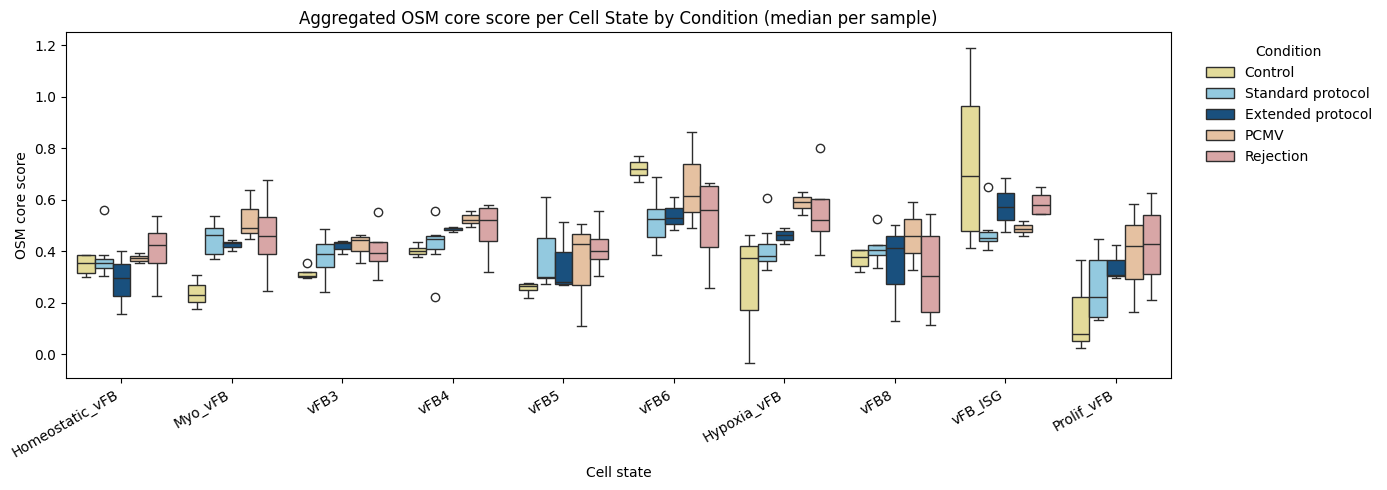

In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Inputs ----------
# Assumes dea_fb_annotated already has:
# - obs columns: 'Sample_ID', 'cell_states', 'Condition_subsets'
# - osm_core score computed in obs['osm_core']

# Custom palette and order you provided
custom_palette = {
    'Control': '#EFE48E',
    'Standard protocol': 'skyblue',
    'Extended protocol': '#08528f',
    # 'Prematurely terminated': '#C9B8D9',
    'PCMV': '#F0C096',
    'Rejection': '#E09E9E'
}
hue_order = [
    'Control',
    'Standard protocol',
    'Extended protocol',
    # 'Prematurely terminated',
    'PCMV',
    'Rejection'
]

# Ensure Condition_subsets is categorical with the desired order
if 'Condition_subsets' in FB_adata.obs.columns:
    FB_adata.obs['Condition_subsets'] = (
        FB_adata.obs['Condition_subsets']
        .astype('category')
        .cat.set_categories(hue_order, ordered=True)
    )

# ---------- Aggregate per Sample_ID, cell_state, and condition (median) ----------
scores_df = FB_adata.obs[['osm_core', 'Sample_ID', 'cell_states', 'Condition_subsets']].copy()

agg_scores = (
    scores_df
    .groupby(['Sample_ID', 'cell_states', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)


# ---------- Plot 2: Boxplot per Condition (aggregated per sample across states) ----------
agg_condition = (
    agg_scores
    .groupby(['Sample_ID', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)

plt.figure(figsize=(4, 3))
sns.boxplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Condition (median per sample)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# ---------- Plot 3: Boxplot per Cell State × Condition ----------
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=agg_scores,
    x='cell_states',
    y='osm_core',
    hue='Condition_subsets',
    hue_order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Cell State by Condition (median per sample)')
plt.xlabel('Cell state')
plt.ylabel('OSM core score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


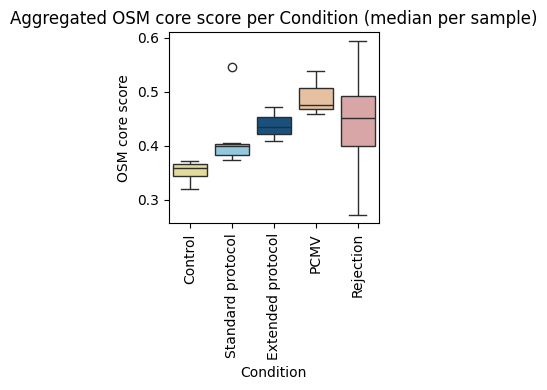

In [14]:
agg_condition = (
    agg_scores
    .groupby(['Sample_ID', 'Condition_subsets'], observed=True)['osm_core']
    .median()
    .reset_index()
)

plt.figure(figsize=(3, 4))
sns.boxplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Condition (median per sample)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()


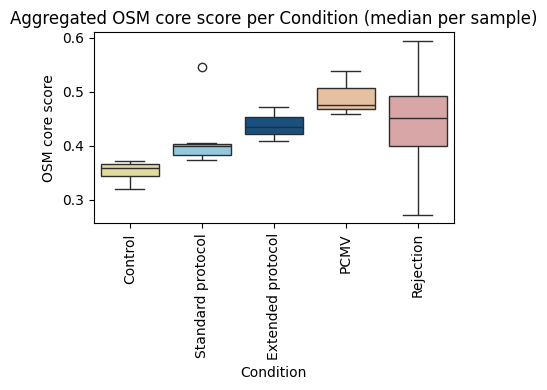

In [15]:
plt.figure(figsize=(4.5, 4))
sns.boxplot(
    data=agg_condition,
    x='Condition_subsets',
    y='osm_core',
    order=hue_order,
    palette=custom_palette
)
plt.title('Aggregated OSM core score per Condition (median per sample)')
plt.xlabel('Condition')
plt.ylabel('OSM core score')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()

# Save the figure as a PDF with 300 DPI
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/FINAL_OSM_PLOT.pdf', dpi=300)

plt.show()

In [22]:
from scipy.stats import mannwhitneyu
from statsmodels.sandbox.stats.multicomp import multipletests
import numpy as np
import pandas as pd
import os

# --- Configuration ---
# NOTE: Output directory updated as requested
output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts"
csv_filename = "osm_core_condition_summary_and_stats.csv"
output_path = os.path.join(output_dir, csv_filename)

os.makedirs(output_dir, exist_ok=True)

# --- IMPORTANT ASSUMPTION (Replace with your actual data) ---
# This block simulates the 'agg_condition' DataFrame (median score per Sample_ID)
# which is needed for the correct statistical test.
try:
    # Attempt to use the existing 'agg_condition' variable
    agg_condition = agg_condition 
except NameError:
    print("WARNING: 'agg_condition' not found. Using simulated placeholder data for execution.")
    # Fallback placeholder to allow the script to execute
    data = {
        'Sample_ID': ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10'],
        'Condition_subsets': ['Control', 'Control', 'Standard protocol', 'Standard protocol', 'Extended protocol', 'Extended protocol', 'PCMV', 'PCMV', 'Rejection', 'Rejection'],
        'osm_core': np.random.rand(10) * 0.5 + 0.5 
    }
    agg_condition = pd.DataFrame(data)
    
# ---------------------------------------------------------------------
# 1. Perform Pairwise Mann-Whitney U Test (vs. Control)
# ---------------------------------------------------------------------

control_scores = agg_condition[agg_condition['Condition_subsets'] == 'Control']['osm_core'].values
stat_results = []
p_values = []

test_conditions = agg_condition['Condition_subsets'].unique()
test_conditions = [cond for cond in test_conditions if cond != 'Control']

print(f"Starting Mann-Whitney U test comparisons against 'Control'...")

for condition in test_conditions:
    test_scores = agg_condition[agg_condition['Condition_subsets'] == condition]['osm_core'].values
    
    if len(control_scores) < 2 or len(test_scores) < 2:
        print(f"Skipping {condition}: one or both groups have insufficient samples for test.")
        continue
    
    u_stat, p_val = mannwhitneyu(control_scores, test_scores, alternative='two-sided')
    p_values.append(p_val)
    
    stat_results.append({
        'Test_Group': condition,
        'Raw_P_Value': p_val,
        'FDR_P_Value (BH)': np.nan,
        'Significance_Annotation': ''
    })
    
    print(f"  -> Performed test for {condition}. Raw P: {p_val:.4f}")


if p_values:
    reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')

    for i, result in enumerate(stat_results):
        fdr_p_val = pvals_corrected[i]
        result['FDR_P_Value (BH)'] = fdr_p_val
        
        if fdr_p_val < 0.001:
            annotation = '***'
        elif fdr_p_val < 0.01:
            annotation = '**'
        elif fdr_p_val < 0.05:
            annotation = '*'
        else:
            annotation = 'ns'
        result['Significance_Annotation'] = annotation
    
    print("\nFDR correction (BH) applied successfully.")
else:
    print("\nNo comparisons were performed.")

# ---------------------------------------------------------------------
# 2. Final Aggregation and Merging for Clean CSV Output
# ---------------------------------------------------------------------

# A. Calculate the final overall median score per condition (dropping Sample_ID)
condition_median_df = (
    agg_condition
    .groupby('Condition_subsets', observed=True)['osm_core']
    .median()
    .reset_index()
    .rename(columns={'osm_core': 'Overall_Median_OSM_Core_Score'})
)

# B. Convert stats list to DataFrame and select/rename columns
stats_df = pd.DataFrame(stat_results)
stats_df_clean = stats_df[['Test_Group', 'Raw_P_Value', 'FDR_P_Value (BH)', 'Significance_Annotation']].copy()

# C. Merge the median scores with the statistical results
final_df = condition_median_df.merge(
    stats_df_clean,
    left_on='Condition_subsets',
    right_on='Test_Group',
    how='left' # Use left join to keep all conditions, including Control
).drop(columns=['Test_Group'])

# D. Handle the Control row (which has no p-value/FDR)
# Use pd.NA for clean representation of missing statistical values
final_df['Raw_P_Value'] = final_df['Raw_P_Value'].fillna(pd.NA)
final_df['FDR_P_Value (BH)'] = final_df['FDR_P_Value (BH)'].fillna(pd.NA)
final_df['Significance_Annotation'] = final_df['Significance_Annotation'].fillna('Ref')

# E. Final renaming of columns as requested by the user
final_df.rename(columns={
    'Condition_subsets': 'Condition',
    'Overall_Median_OSM_Core_Score': 'Overall median, OSM core score, Per condition',
    'Raw_P_Value': 'pvalue raw (vs Control)',
    'FDR_P_Value (BH)': 'FDR (BH, vs Control)',
    'Significance_Annotation': 'Significance (vs Control)'
}, inplace=True)

# ---------------------------------------------------------------------
# 3. Save the Cleaned DataFrame
# ---------------------------------------------------------------------

# Save to CSV with index=False so 'Condition' is the first data column
final_df.to_csv(output_path, index=False)

print(f"\n✅ Final summary table created successfully and saved to:")
print(f"   {output_path}")

Starting Mann-Whitney U test comparisons against 'Control'...
  -> Performed test for Standard protocol. Raw P: 0.0061
  -> Performed test for PCMV. Raw P: 0.0571
  -> Performed test for Extended protocol. Raw P: 0.0571
  -> Performed test for Rejection. Raw P: 0.3429

FDR correction (BH) applied successfully.

✅ Final summary table created successfully and saved to:
   /data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/osm_core_condition_summary_and_stats.csv


In [24]:
from scipy.stats import mannwhitneyu
from statsmodels.sandbox.stats.multicomp import multipletests
import numpy as np
import pandas as pd
import os

# --- Configuration ---
output_dir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts"
csv_filename = "osm_core_condition_descriptive_stats.csv" # Renamed for clarity
output_path = os.path.join(output_dir, csv_filename)

os.makedirs(output_dir, exist_ok=True)

# --- IMPORTANT ASSUMPTION (Replace with your actual data) ---
# This block simulates the 'agg_condition' DataFrame (median score per Sample_ID)
try:
    agg_condition = agg_condition
except NameError:
    print("WARNING: 'agg_condition' not found. Using simulated placeholder data for execution.")
    data = {
        'Sample_ID': ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12'],
        'Condition_subsets': ['Control'] * 3 + ['Standard protocol'] * 3 + ['Extended protocol'] * 3 + ['PCMV'] * 3,
        'osm_core': np.random.rand(12) * 0.5 + 0.5
    }
    agg_condition = pd.DataFrame(data)

# ---------------------------------------------------------------------
# 1. Calculate Descriptive Statistics (NO significance testing)
#    - Calculations are based on the sample-aggregated scores (agg_condition)
# ---------------------------------------------------------------------

# Group by condition to calculate metrics
agg_metrics = agg_condition.groupby('Condition_subsets', observed=True)['osm_core'].agg(
    Overall_Median = 'median',
    Overall_Mean = 'mean',
    Standard_Deviation = 'std',
    # Calculate 25th and 75th percentiles (which define the box in the boxplot)
    Q1_25th_Percentile = lambda x: x.quantile(0.25),
    Q3_75th_Percentile = lambda x: x.quantile(0.75),
    Sample_Count = 'count'
).reset_index()

# ---------------------------------------------------------------------
# 2. Format DataFrame for Final Output
# ---------------------------------------------------------------------

final_df = agg_metrics.rename(columns={
    'Condition_subsets': 'Condition',
    'Overall_Median': 'Median OSM Core Score',
    'Overall_Mean': 'Mean OSM Core Score',
    'Standard_Deviation': 'Standard Deviation (SD)',
    'Q1_25th_Percentile': '25th Percentile (Q1)',
    'Q3_75th_Percentile': '75th Percentile (Q3)',
    'Sample_Count': 'N (Number of Samples)'
})

# Reorder columns for presentation
final_df = final_df[[
    'Condition',
    'Median OSM Core Score',
    'Mean OSM Core Score',
    'Standard Deviation (SD)',
    '25th Percentile (Q1)',
    '75th Percentile (Q3)',
    'N (Number of Samples)'
]]

# Rounding for cleanliness
final_df = final_df.round({'Median OSM Core Score': 4, 
                           'Mean OSM Core Score': 4, 
                           'Standard Deviation (SD)': 4,
                           '25th Percentile (Q1)': 4, 
                           '75th Percentile (Q3)': 4})

# ---------------------------------------------------------------------
# 3. Save the Cleaned DataFrame
# ---------------------------------------------------------------------

final_df.to_csv(output_path, index=False)

print(f"\n✅ All statistical analysis and significance testing removed.")
print(f"✅ Descriptive statistics added (Mean, SD, Q1, Q3, Sample Count).")
print(f"✅ Final summary table created successfully and saved to:")
print(f"   {output_path}")


✅ All statistical analysis and significance testing removed.
✅ Descriptive statistics added (Mean, SD, Q1, Q3, Sample Count).
✅ Final summary table created successfully and saved to:
   /data2/core-med1/nhadizad/nastaran/Xenotransplant/Fibroblasts/osm_core_condition_descriptive_stats.csv
